#Parte 1: Introducción y Entendimiento del Problema
##1.1. Contexto del Problema
La salud mental es un pilar fundamental del bienestar y el éxito académico de los estudiantes universitarios. Sin embargo, este grupo demográfico enfrenta una combinación única de presiones, como la carga académica, el estrés financiero y la transición a la independencia, que los hacen particularmente vulnerables a condiciones como la depresión. La detección temprana y la intervención son cruciales para mitigar los impactos negativos en su vida personal y académica.
##1.2. Objetivos del Proyecto
Este proyecto de ciencia de datos aborda este desafío desde una doble perspectiva, utilizando técnicas de aprendizaje automático para extraer insights valiosos de un conjunto de datos sobre estudiantes.
* Objetivo Primario (Predicción): Desarrollar un modelo de Aprendizaje
Supervisado capaz de predecir con alta fiabilidad si un estudiante está experimentando síntomas de depresión, basándose en sus características demográficas, académicas y de estilo de vida. El fin último es sentar las bases para un sistema de alerta temprana.

* Objetivo Secundario (Segmentación): Aplicar técnicas de Aprendizaje No Supervisado para identificar si existen grupos o "perfiles" de estudiantes con patrones de comportamiento y estrés similares. Esto nos permitirá comprender mejor los distintos arquetipos de riesgo y bienestar dentro de la población estudiantil, más allá de la simple etiqueta de "depresión".


#Parte 2: Preparación del Entorno y Carga de Datos
##2.1. Importación de Librerías
(Esta sección contiene todo el código para importar las librerías de pandas, numpy, seaborn, matplotlib, sklearn, etc. Es el bloque de configuración inicial).

In [ ]:
# Librerías para manipulación y análisis de datos
import pandas as pd
import numpy as np
import sklearn

# Librerías para visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías para pre-procesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Librerías para Aprendizaje Supervisado
from sklearn.ensemble import RandomForestClassifier # O RandomForestRegressor
from xgboost import XGBClassifier # O XGBRegressor

# Para ELM, necesitarás una librería como 'sklearn-elm' o implementarla
from sklearn.model_selection import cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score
from sklearn.feature_selection import RFE
from sklearn.decomposition import PCA

##2.2. Carga del Dataset y Descripción Inicial

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive/')

PATH = 'gdrive/My Drive/datasets/'

df = pd.read_csv(PATH + 'student_depression_dataset.csv')

print("Dimensiones del dataset:", df.shape)
print("\nPrimeras 5 filas:")
display(df.head())
print("\nInformación general del DataFrame:")
df.info()
print("\nResumen estadístico de las variables numéricas:")
display(df.describe())

Mounted at /content/gdrive/
Dimensiones del dataset: (27901, 18)

Primeras 5 filas:


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0



Información general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                    

,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Depression
count,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000
mean,70442.149421,25.822300,3.141214,0.000430,7.656104,2.943837,0.000681,7.156984,0.585499
std,40641.175216,4.905687,1.381465,0.043992,1.470707,1.361148,0.044394,3.707642,0.492645
min,2.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,35039.000000,21.000000,2.000000,0.000000,6.290000,2.000000,0.000000,4.000000,0.000000
50%,70684.000000,25.000000,3.000000,0.000000,7.770000,3.000000,0.000000,8.000000,1.000000
75%,105818.000000,30.000000,4.000000,0.000000,8.920000,4.000000,0.000000,10.000000,1.000000
max,140699.000000,59.000000,5.000000,5.000000,10.000000,5.000000,4.000000,12.000000,1.000000




#Parte 3: Análisis Exploratorio de Datos (EDA) - Dataset Original

## 3.1. Introducción al EDA

El Análisis Exploratorio de Datos (EDA) es una fase crítica en la que "dialogamos" con los datos. El objetivo es descubrir patrones, identificar anomalías, probar hipótesis y verificar supuestos a través de la estadística descriptiva y la visualización. En este proyecto, el EDA nos ayudará a entender la prevalencia de la depresión, las características de la población estudiantil y las relaciones preliminares entre las variables antes de aplicar algoritmos complejos.


## 3.2. Analisis General
En esta sección se presenta una visión global del conjunto de datos utilizado para estudiar los factores asociados con la depresión en estudiantes universitarios. El dataset, compuesto por 27.901 registros y 18 variables de naturaleza demográfica, académica, de estilo de vida y de salud mental, constituye la base para la construcción de un modelo predictivo orientado a identificar estudiantes con alta probabilidad de padecer depresión.

El análisis general permite comprender la estructura del dataset, los tipos de variables involucradas, la presencia de valores faltantes y la consistencia del contenido, estableciendo así los cimientos necesarios para un análisis exploratorio más profundo y para la correcta selección de técnicas de modelado.

In [ ]:
#Listado de todos los valores distintos que existen en cada columna "relevante" de estudio.
columns_to_exclude = ['id', 'City', 'Profession', 'CGPA', 'Age']

for column in df.columns:
    if column not in columns_to_exclude:
        print(f"\n Valores únicos para la columna '{column}':")
        print(df[column].unique())
        #print("\n")
        print(f"\n Cantidad de cada valor para la columna '{column}':")
        print(df[column].value_counts())
        print("\n")


 Valores únicos para la columna 'Gender':
['Male' 'Female']

 Cantidad de cada valor para la columna 'Gender':
Gender
Male      15547
Female    12354
Name: count, dtype: int64



 Valores únicos para la columna 'Academic Pressure':
[5. 2. 3. 4. 1. 0.]

 Cantidad de cada valor para la columna 'Academic Pressure':
Academic Pressure
3.0    7462
5.0    6296
4.0    5155
1.0    4801
2.0    4178
0.0       9
Name: count, dtype: int64



 Valores únicos para la columna 'Work Pressure':
[0. 5. 2.]

 Cantidad de cada valor para la columna 'Work Pressure':
Work Pressure
0.0    27898
5.0        2
2.0        1
Name: count, dtype: int64



 Valores únicos para la columna 'Study Satisfaction':
[2. 5. 3. 4. 1. 0.]

 Cantidad de cada valor para la columna 'Study Satisfaction':
Study Satisfaction
4.0    6359
2.0    5838
3.0    5821
1.0    5451
5.0    4422
0.0      10
Name: count, dtype: int64



 Valores únicos para la columna 'Job Satisfaction':
[0. 3. 4. 2. 1.]

 Cantidad de cada valor para la columna

##3.3. Análisis Univariado
El análisis univariado se enfoca en examinar cada variable de manera individual, explorando su distribución, comportamiento y posibles particularidades. Dado que el objetivo del proyecto es identificar los factores más relevantes asociados al riesgo de depresión, esta etapa resulta fundamental para comprender cómo se comportan los atributos demográficos, académicos, emocionales y de hábitos de los estudiantes.

A través de esta revisión, se detectan valores atípicos, asimetrías, patrones relevantes y características que pueden influir en la interpretación de los datos y en el desempeño de los modelos predictivos.

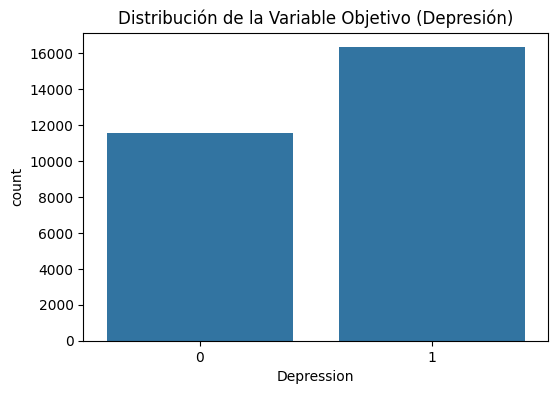

Distribución porcentual de la depresión:
 Depression
1    0.585499
0    0.414501
Name: proportion, dtype: float64


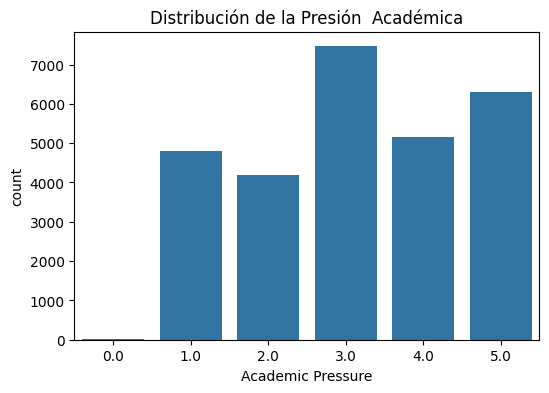

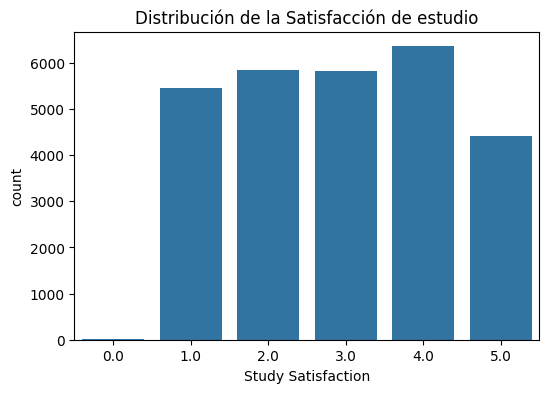

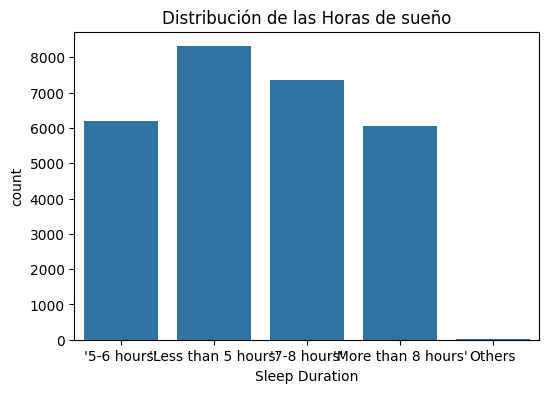

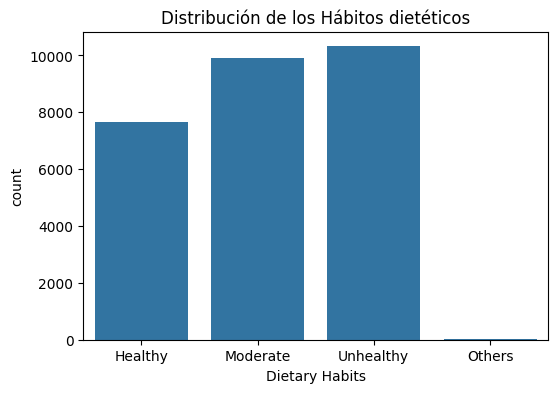

In [ ]:
# Análisis de la variable objetivo 'Depression'
plt.figure(figsize=(6, 4))
sns.countplot(x='Depression', data=df)
plt.title('Distribución de la Variable Objetivo (Depresión)')
plt.show()
print("Distribución porcentual de la depresión:\n", df['Depression'].value_counts(normalize=True))


# Distribución de Presion Academica
plt.figure(figsize=(6, 4))
sns.countplot(x='Academic Pressure', data=df)
plt.title('Distribución de la Presión  Académica')
plt.show()


# Distribución de la satisfaccion de estudio
plt.figure(figsize=(6, 4))
sns.countplot(x='Study Satisfaction', data=df)
plt.title('Distribución de la Satisfacción de estudio')
plt.show()


# Distribución de las horas de sueño
plt.figure(figsize=(6, 4))
sns.countplot(x='Sleep Duration', data=df)
plt.title('Distribución de las Horas de sueño')
plt.show()


# Distribución de los habitos de dieta
plt.figure(figsize=(6, 4))
sns.countplot(x='Dietary Habits', data=df)
plt.title('Distribución de los Hábitos dietéticos')
plt.show()


##3.4. Analisis de Outliers para Variables Numéricas
Para identificar valores extremos en las variables numéricas del dataset, se utilizaron diagramas de caja (boxplots). Este análisis permite detectar observaciones que se desvían del patrón general de los datos, las cuales pueden influir en la interpretación y en el desempeño de modelos posteriores. A continuación, se presentan los principales outliers encontrados y su posible impacto en el estudio.

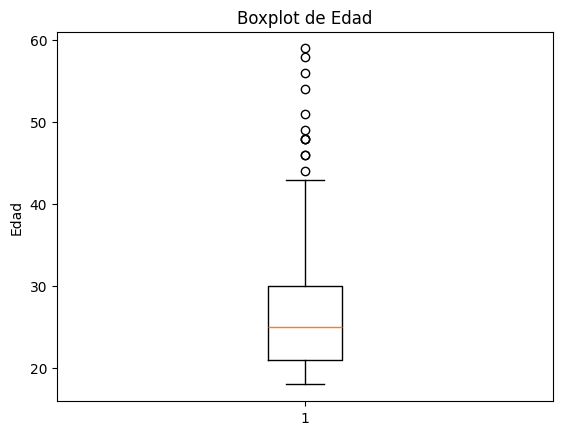

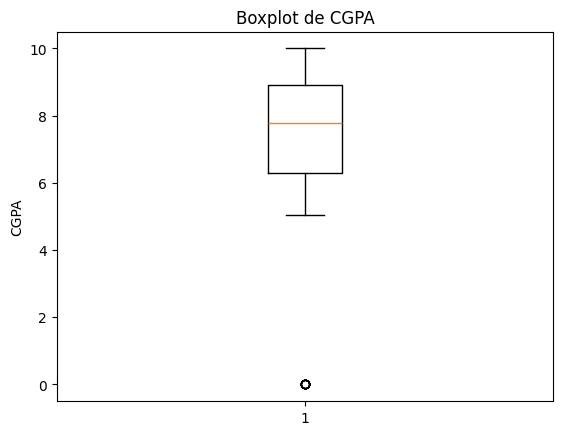

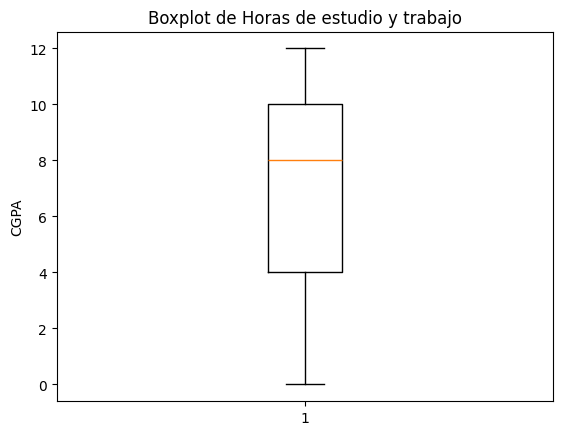

In [ ]:
plt.boxplot(df['Age'])
plt.title('Boxplot de Edad')
plt.ylabel('Edad')
plt.show()

plt.boxplot(df['CGPA'])
plt.title('Boxplot de CGPA')
plt.ylabel('CGPA')
plt.show()

plt.boxplot(df['Work/Study Hours'])
plt.title('Boxplot de Horas de estudio y trabajo')
plt.ylabel('CGPA')
plt.show()

##3.5. Conclusiones del EDA - Dataset Original

* Se identifican outliers en la variable Age, correspondientes a estudiantes mayores de 40 años, lo cual representa casos poco frecuentes dentro del dataset.

* La variable CGPA presenta valores atípicos extremadamente bajos, específicamente por debajo de 1, lo cual podría indicar situaciones académicas excepcionales o posibles errores de carga.

* Existe una cantidad muy baja de estudiantes con presión académica igual a 0.0, indicando que la mayoría experimenta al menos cierto nivel de presión.

* También se observa poca representatividad en la categoría 0.0 de Study Satisfaction, lo que sugiere que casi todos los estudiantes presentan algún grado de satisfacción con sus estudios.

* La categoría “others” en Sleep Duration es minoritaria, lo que indica que la mayoría de respuestas se concentra en rangos normales de sueño.

* La categoría “others” en Dietary Habits también tiene muy baja frecuencia, funcionando como categoría residual sin relevancia predominante en la distribución general.

#Parte 4: Pre-procesamiento de Datos

##4.1. Introducción al Pre-procesamiento

Los algoritmos de Machine Learning requieren que los datos estén en un formato numérico, limpio y consistente. En esta fase, transformaremos nuestro dataset crudo en una matriz adecuada para el entrenamiento. Esto incluye la codificación de variables categóricas para convertirlas en números ¿y el escalado de variables numéricas para que tengan un rango similar??, lo cual es esencial para el buen funcionamiento de algoritmos sensibles a la distancia como K-Means.

## 4.2. Transformación y estandarización de valores para facilitar el análisis

Con el objetivo de optimizar el proceso de entrenamiento y mejorar la interpretabilidad de los resultados, se realizaron diversas transformaciones sobre el conjunto de datos. Estas incluyeron la agrupación de categorías para reducir la complejidad, la eliminación de atributos y registros no relevantes para el objetivo del estudio, así como la conversión y mapeo de valores hacia formatos más adecuados para su tratamiento por los modelos de aprendizaje automático.
Estas acciones permitieron no solo homogeneizar la estructura de los datos, sino también mejorar la coherencia semántica de las variables y facilitar su posterior análisis estadístico y modelado.

###4.2.1. Mapeos de variables ordinarias con valores

In [ ]:
# Mapeo horas de sueño
df['Sleep Duration'] = df['Sleep Duration'].map({"'5-6 hours'": 5.5, "'Less than 5 hours'": 4, "'7-8 hours'": 7.5, "'More than 8 hours'": 9, 'Others': 0}).astype(float)

# Mapeo genero (0: Hombres, 1: Mujeres)
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

# Mapeo historial familair (0: No hay, 1: Si hay)
df['Family History of Mental Illness'] = df['Family History of Mental Illness'].map({'No': 0, 'Yes': 1})

# Mapeo pensamientos suicidas (0: No tuvo, 1: si tuvo)
df['Have you ever had suicidal thoughts ?'] = df['Have you ever had suicidal thoughts ?'].map({'No': 0, 'Yes': 1})

# Mapeo el nivel educativo (0: Secundario, 1: Superior)
df['Degree'] = df['Degree'].apply(lambda x: 0 if x == "'Class 12'" else 1)

# Mapeo de habitos de dieta
df['Dietary Habits'] = df['Dietary Habits'].map(
    {
        'Healthy': 0,
        'Moderate': 1,
        'Unhealthy': 2,
        'Others': 3
    }
)

print(df.head())


   id  Gender   Age           City Profession  Academic Pressure  \
0   2       0  33.0  Visakhapatnam    Student                5.0   
1   8       1  24.0      Bangalore    Student                2.0   
2  26       0  31.0       Srinagar    Student                3.0   
3  30       1  28.0       Varanasi    Student                3.0   
4  32       1  25.0         Jaipur    Student                4.0   

   Work Pressure  CGPA  Study Satisfaction  Job Satisfaction  Sleep Duration  \
0            0.0  8.97                 2.0               0.0             5.5   
1            0.0  5.90                 5.0               0.0             5.5   
2            0.0  7.03                 5.0               0.0             4.0   
3            0.0  5.59                 2.0               0.0             7.5   
4            0.0  8.13                 3.0               0.0             5.5   

   Dietary Habits  Degree  Have you ever had suicidal thoughts ?  \
0               0       1                 

### 4.2.2. Eliminación de Filas

Para garantizar la coherencia del análisis y mantener el enfoque del estudio en la población objetivo, se aplicaron criterios de filtrado que permitieron descartar registros que no cumplían las condiciones definidas. En particular, se conservaron únicamente aquellos casos que cumplen con:

* Estudiantes entre 18 y 34 años, considerados dentro del rango etario de interés para este estudio.

* Situación laboral: desempleado, es decir, estudiantes que no se encuentran trabajando al momento del relevamiento.

* Registros sin valores faltantes o ambiguos en el atributo Financial Stress, eliminando específicamente aquellos que contenían el valor “?”.

Estos filtros permiten trabajar con un subconjunto de datos más consistente, representativo y adecuado para los objetivos del proyecto.

In [ ]:
#Contamos registros que esten fuera de nuestro marco de estudio
print(df[df['Age'] >= 35].shape)
print(df[df['Profession'] != 'Student'].shape)
print(df[df['Work Pressure'] != 0].shape)
print(df[df['Job Satisfaction'] != 0].shape)

#Contamos registros con que tienen valores no reconocibles ni relacionales
print(df[df['Financial Stress'] == '?'].shape) # estres academico no reconocible, con "?"
print(df[df['Sleep Duration'] == 0].shape) # 0 horas de sueño
print(df[df['Academic Pressure'] == 0].shape) # 0 en presion academica
print(df[df['Study Satisfaction'] == 0].shape) # 0 en satisfaccion en el estudio
print(df[df['Dietary Habits'] == 3].shape) # habitos de dieta no reconocibles, como "otros"
print(df[df['CGPA'] == 0].shape) # promedio igual a 0

(49, 18)
(31, 18)
(3, 18)
(8, 18)
(3, 18)
(18, 18)
(9, 18)
(10, 18)
(12, 18)
(9, 18)


In [ ]:
#Eliminamos registros que esten fuera del marco de estudio (basado en el conteo anterior)
print("Dimensiones originales: ", df.shape)
df.drop(df[df['Financial Stress'] == '?'].index, inplace=True)
df.drop(df[df['Age'] >= 35].index, inplace=True)
df.drop(df[df['Profession'] != 'Student'].index, inplace=True)
df.drop(df[df['Work Pressure'] != 0].index, inplace=True)
df.drop(df[df['Job Satisfaction'] != 0].index, inplace=True)
df.drop(df[df['Sleep Duration'] == 0].index, inplace=True)
df.drop(df[df['Academic Pressure'] == 0].index, inplace=True)
df.drop(df[df['Study Satisfaction'] == 0].index, inplace=True)
df.drop(df[df['Dietary Habits'] == 3].index, inplace=True)
df.drop(df[df['CGPA'] == 0].index, inplace=True)


print("Dimensiones Modificadas :", df.shape)

Dimensiones originales:  (27901, 18)
Dimensiones Modificadas : (27774, 18)


### 4.2.3. Casteo de atributos
Se realizó el casteo de las columnas originalmente definidas como object hacia tipos de datos numéricos (principalmente enteros), con el fin de facilitar su manipulación durante el análisis exploratorio y las etapas posteriores de modelado.

In [ ]:
df['Financial Stress'] = df['Financial Stress'].astype(float).astype(int)
df['Age'] = df['Age'].astype(float).astype(int)
df['Study Satisfaction'] = df['Study Satisfaction'].astype(float).astype(int)
df['Dietary Habits'] = df['Dietary Habits'].astype(float).astype(int)
df['Academic Pressure'] = df['Academic Pressure'].astype(float).astype(int)

### 4.2.4. Redefinición de Columnas

Con el fin de realizar un análisis exclusivamente enfocado en la población estudiantil, se llevó a cabo un proceso de selección de atributos orientado a conservar únicamente aquellas variables pertinentes al objetivo del estudio. En este contexto, se descartaron los atributos vinculados al ámbito laboral, como Job Satisfaction y Work Pressure, por no resultar relevantes para caracterizar la situación académica y emocional de los estudiantes analizados.

Esta redefinición de columnas permite trabajar con un conjunto de variables más coherente y alineado con el propósito central del proyecto, evitando la presencia de información que podría introducir ruido o desviar la interpretación de los resultados.

In [ ]:
#Columnas originales
df.columns

Index(['id', 'Gender', 'Age', 'City', 'Profession', 'Academic Pressure',
       'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction',
       'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression'],
      dtype='object')

In [ ]:
df = df.rename(columns={'Have you ever had suicidal thoughts ?': 'Suicidal Thoughts', 'Family History of Mental Illness': 'Family History'})
df = df[['Gender', 'Age', 'Academic Pressure', 'CGPA', 'Study Satisfaction', 'Sleep Duration',
         'Dietary Habits', 'Degree', 'Suicidal Thoughts', 'Work/Study Hours',
         'Financial Stress', 'Family History', 'Depression']]

#Parte 5: Análisis Exploratorio de Datos (EDA) - Luego de la limpieza

Una vez definidos los atributos de interés para el estudio, eliminados los registros no relevantes y realizadas las conversiones y recodificaciones necesarias, resulta fundamental llevar a cabo un nuevo análisis exploratorio sobre el conjunto de datos ya depurado. Este análisis permite evaluar la estructura final del dataset, identificar patrones emergentes tras la limpieza y verificar que las transformaciones aplicadas hayan generado un conjunto de datos coherente, consistente y adecuado para el modelado posterior.

In [ ]:
df.describe()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27774 entries, 0 to 27900
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Gender              27774 non-null  int64  
 1   Age                 27774 non-null  int64  
 2   Academic Pressure   27774 non-null  int64  
 3   CGPA                27774 non-null  float64
 4   Study Satisfaction  27774 non-null  int64  
 5   Sleep Duration      27774 non-null  float64
 6   Dietary Habits      27774 non-null  int64  
 7   Degree              27774 non-null  int64  
 8   Suicidal Thoughts   27774 non-null  int64  
 9   Work/Study Hours    27774 non-null  float64
 10  Financial Stress    27774 non-null  int64  
 11  Family History      27774 non-null  int64  
 12  Depression          27774 non-null  int64  
dtypes: float64(3), int64(10)
memory usage: 3.0 MB


##5.1. Distribucion de las Variables
En esta sección se examina la distribución individual de cada variable del conjunto de datos ya depurado. Analizar cómo se comportan las variables —tanto numéricas como categóricas— permite identificar patrones generales, rangos de variación y posibles sesgos en la población estudiada. Comprender estas distribuciones resulta fundamental para interpretar correctamente los resultados posteriores y para evaluar la necesidad de transformaciones, estandarizaciones o recategorizaciones durante el proceso de modelado.

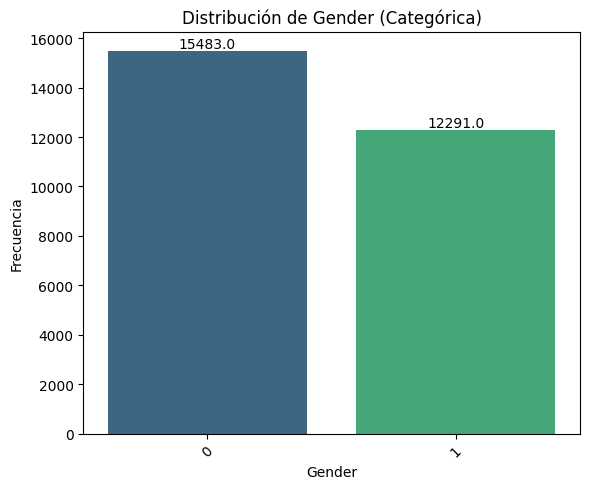

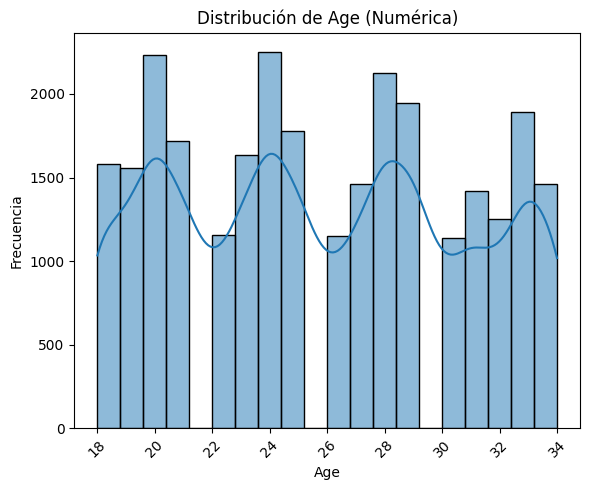

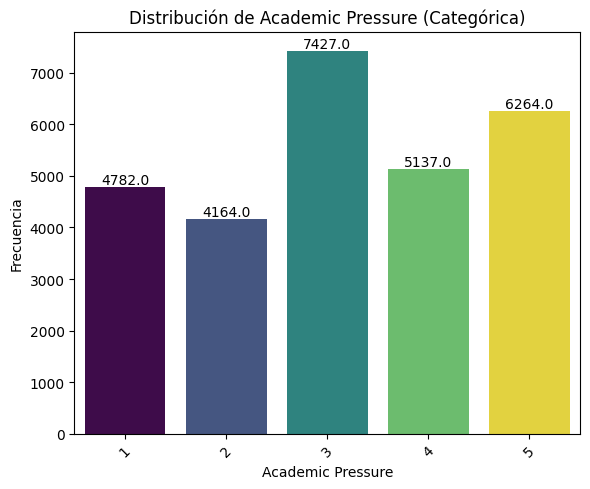

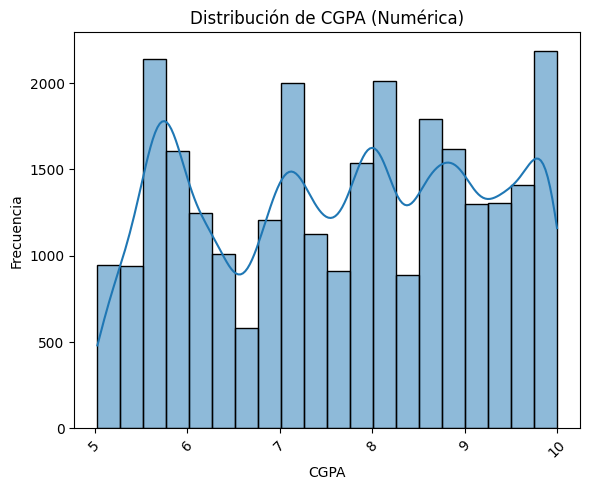

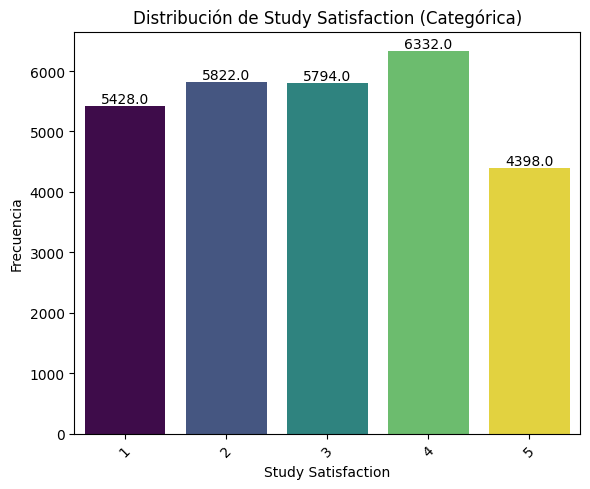

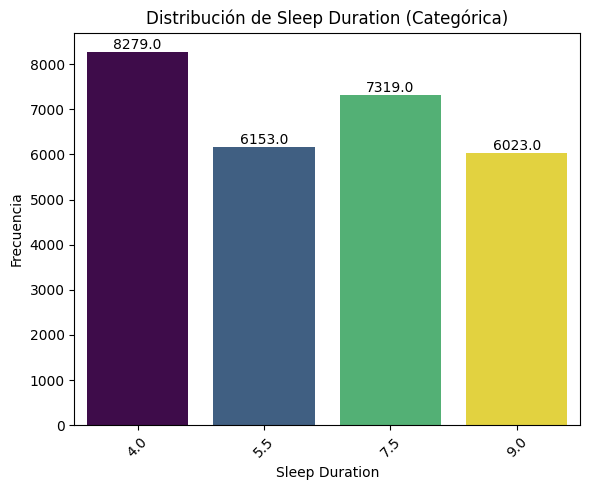

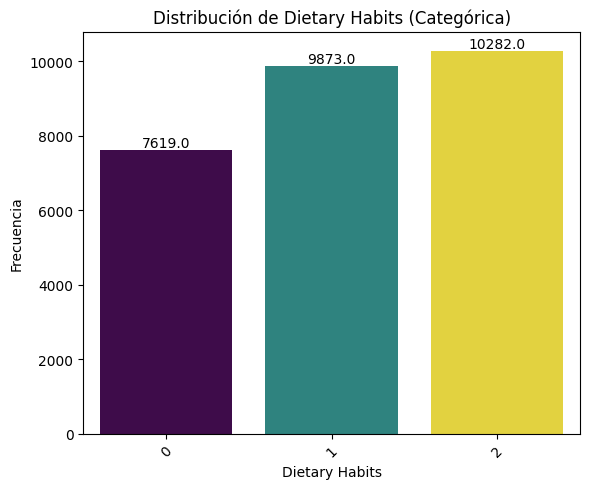

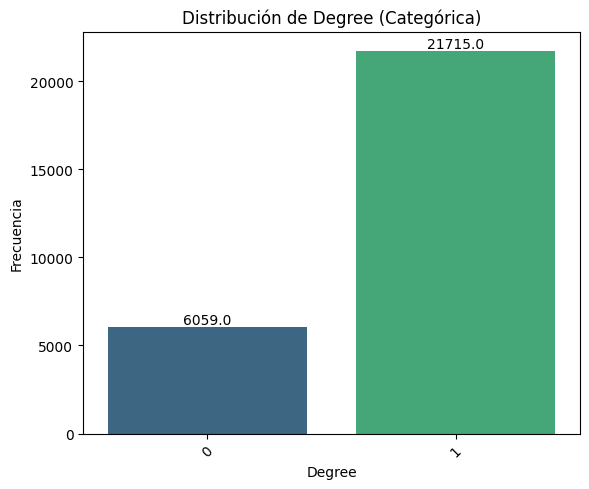

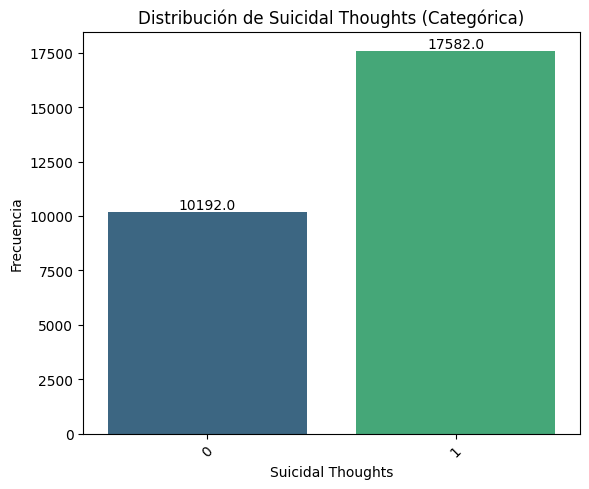

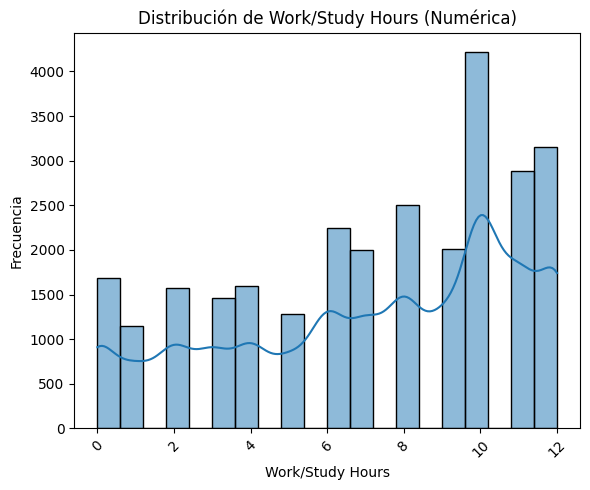

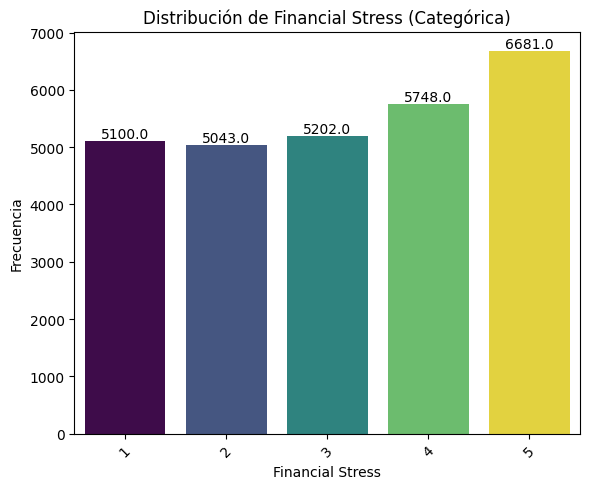

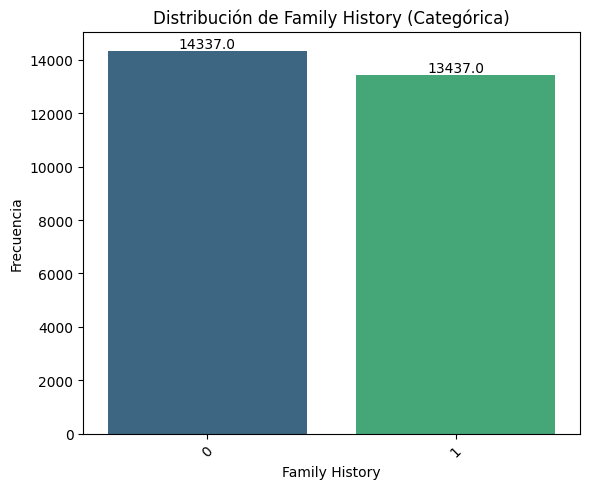

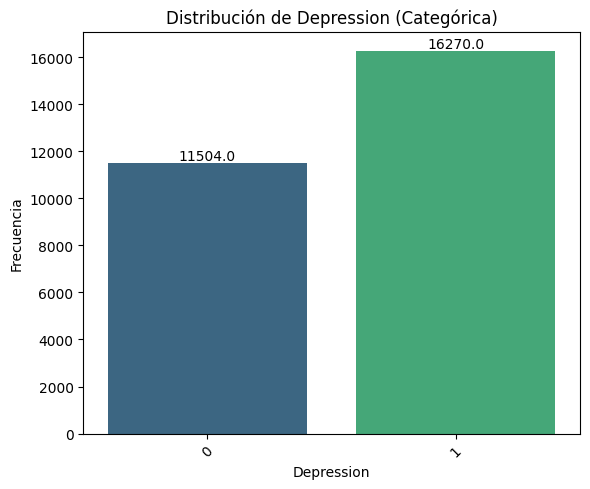

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

variables = [
    'Gender', 'Age', 'Academic Pressure', 'CGPA', 'Study Satisfaction',
    'Sleep Duration', 'Dietary Habits', 'Degree',
    'Suicidal Thoughts',
    'Work/Study Hours', 'Financial Stress',
    'Family History', 'Depression'
]

for col in variables:
    plt.figure(figsize=(6,5))

    # Detectamos el tipo de variable
    if df[col].nunique() < 10:
        # --- VARIABLE CATEGÓRICA ---
        ax = sns.countplot(x=df[col], hue=df[col], palette='viridis', legend=False)
        plt.title(f'Distribución de {col} (Categórica)')
        plt.xlabel(col)
        plt.ylabel("Frecuencia")

        # Añadir número encima de cada barra
        for bar in ax.patches:
            height = bar.get_height()
            ax.annotate(
                f'{height}',
                (bar.get_x() + bar.get_width() / 2, height),
                ha='center', va='bottom', fontsize=10
            )

    else:
        # --- VARIABLE NUMÉRICA ---
        ax = sns.histplot(df[col], kde=True, bins=20)
        plt.title(f'Distribución de {col} (Numérica)')
        plt.xlabel(col)
        plt.ylabel("Frecuencia")

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


##5.2. Distribucion de las variables por estado de depresion (Variables categoricas y numericas)
Aquí se compara la distribución de las variables en función de la variable objetivo Depression, diferenciando entre estudiantes que presentan síntomas depresivos y aquellos que no. Este análisis permite detectar diferencias significativas en hábitos, características demográficas o factores emocionales entre ambos grupos.

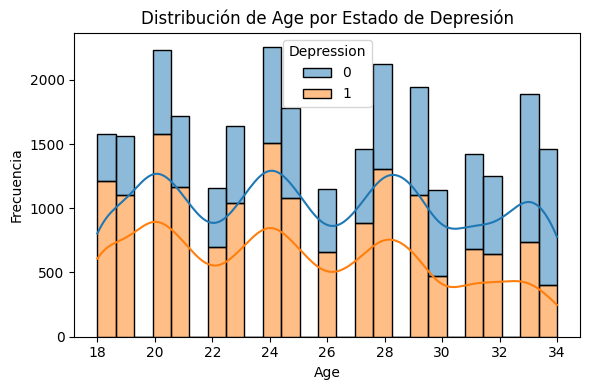

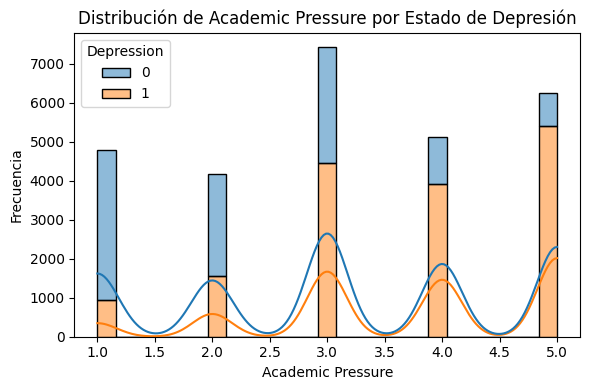

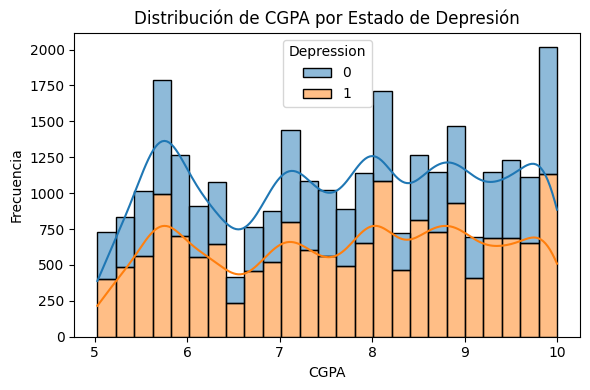

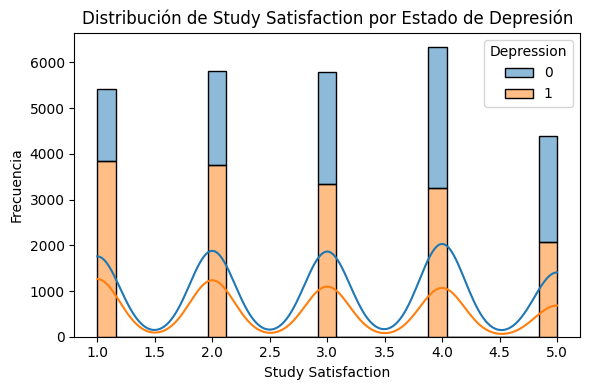

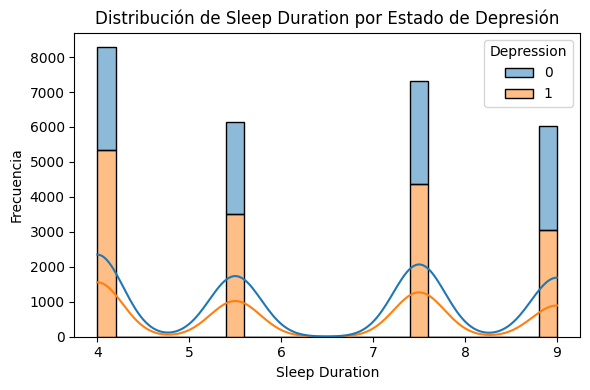

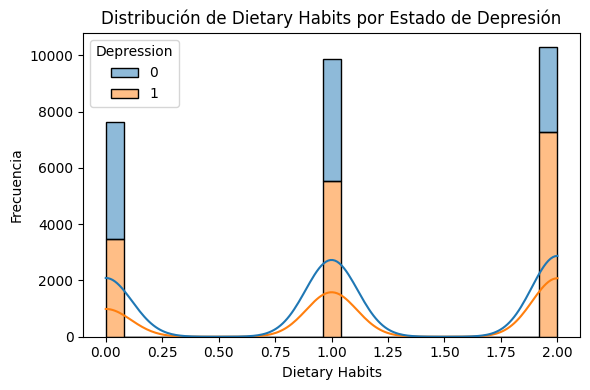

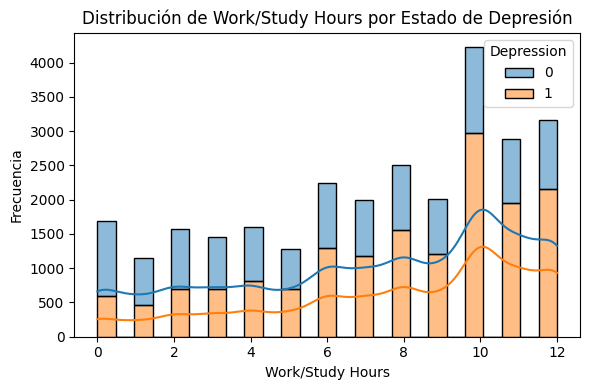

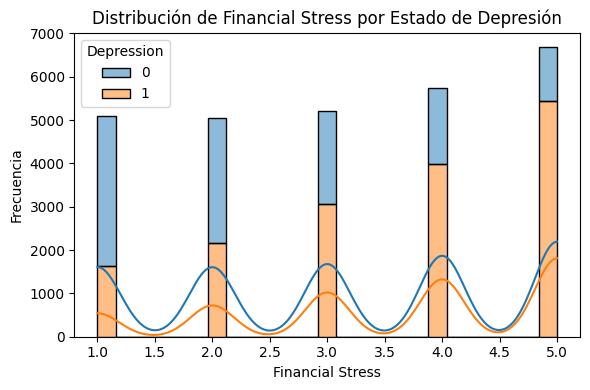

In [ ]:
columns = ['Age', 'Academic Pressure', 'CGPA', 'Study Satisfaction',
           'Sleep Duration', 'Dietary Habits',
           'Work/Study Hours', 'Financial Stress']

for col in columns:
    plt.figure(figsize=(6, 4))
    sns.histplot(data=df, x=col, hue='Depression', kde=True, multiple='stack', bins=25) #probar bins 20
    plt.title(f'Distribución de {col} por Estado de Depresión')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.tight_layout()
    plt.show()


##5.3. Análisis de variables binarias según la variable objetivo

Para comprender cómo se relacionan las distintas variables binarias del dataset con la variable objetivo Depression, se realizó un análisis comparativo mediante gráficos de torta (pie charts). Este enfoque permite visualizar, dentro de cada categoría binaria, la proporción de estudiantes con y sin depresión, facilitando así la identificación de patrones diferenciales entre ambos grupos. Al contrastar estas proporciones para cada atributo binario, es posible detectar asociaciones relevantes o cambios significativos en la distribución de la depresión, lo que contribuye a comprender mejor el peso y la influencia de estos factores en el comportamiento general del conjunto de datos.

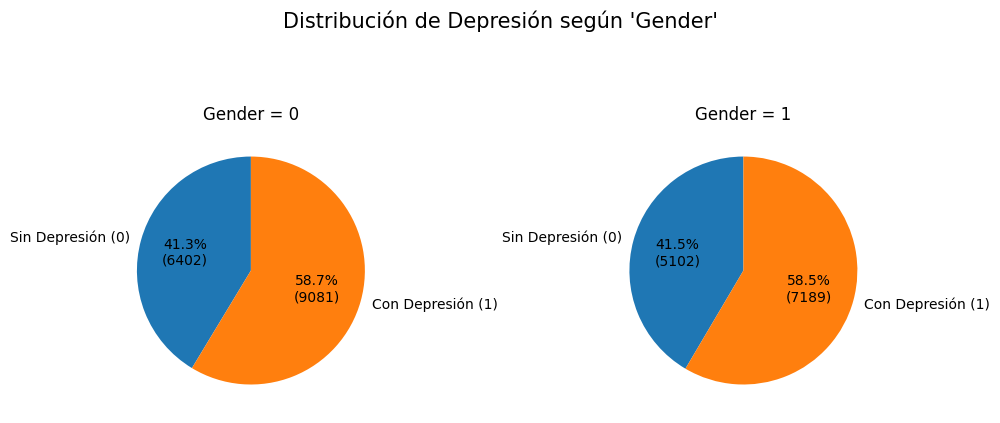

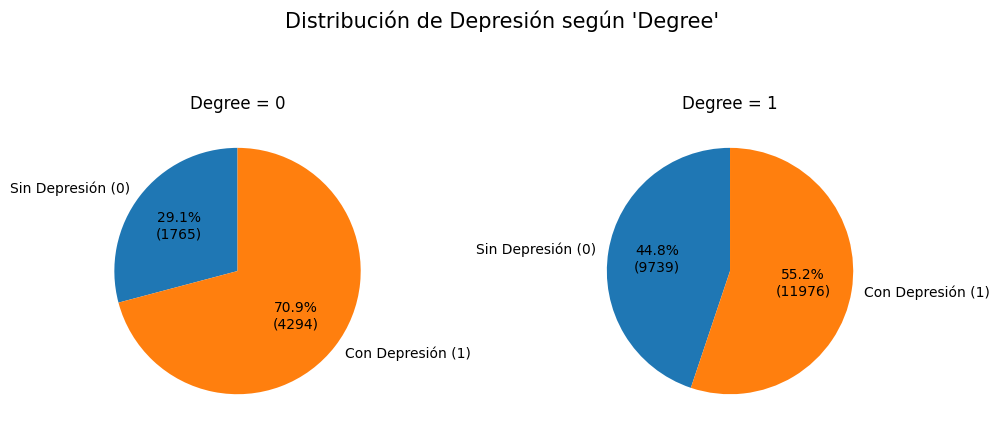

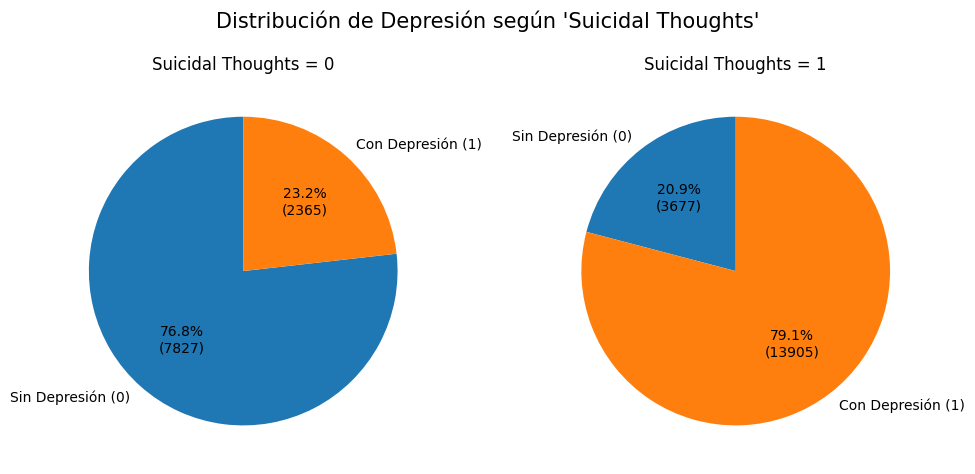

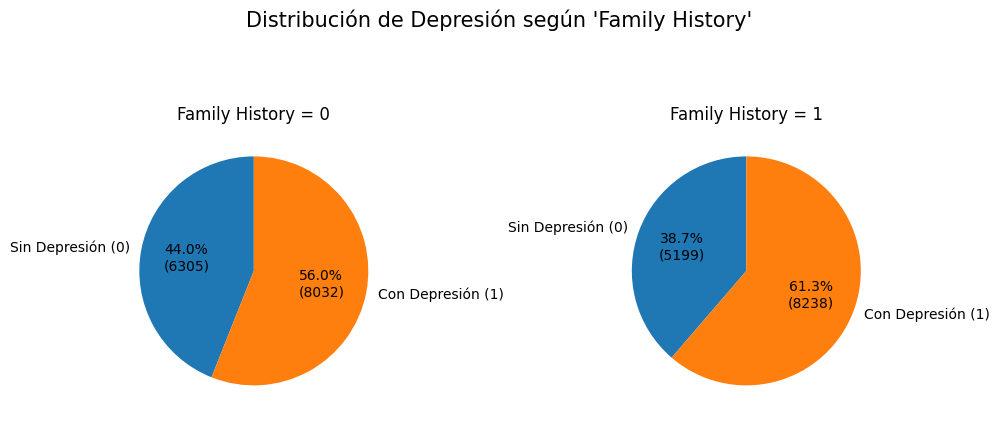

In [ ]:
# Función para mostrar porcentaje + cantidad
def autopct_format(values):
    def inner_autopct(pct):
        total = sum(values)
        count = int(round(pct * total / 100.0))
        return f'{pct:.1f}%\n({count})'
    return inner_autopct

# Variables binarias
columns = ['Gender', 'Degree', 'Suicidal Thoughts',
           'Family History']

target = 'Depression'

for col in columns:

    # Filtrar por cada valor binario
    df_0 = df[df[col] == 0]
    df_1 = df[df[col] == 1]

    # Contar depresión en cada grupo
    counts_0 = df_0[target].value_counts().reindex([0, 1], fill_value=0)
    counts_1 = df_1[target].value_counts().reindex([0, 1], fill_value=0)

    labels = ['Sin Depresión (0)', 'Con Depresión (1)']

    plt.figure(figsize=(10, 5))

    # --- Gráfico: variable = 0 ---
    plt.subplot(1, 2, 1)
    plt.pie(counts_0,
            labels=labels,
            autopct=autopct_format(counts_0),
            startangle=90)
    plt.title(f"{col} = 0")

    # --- Gráfico: variable = 1 ---
    plt.subplot(1, 2, 2)
    plt.pie(counts_1,
            labels=labels,
            autopct=autopct_format(counts_1),
            startangle=90)
    plt.title(f"{col} = 1")

    plt.suptitle(f"Distribución de Depresión según '{col}'", fontsize=15)
    plt.tight_layout()
    plt.show()

##5.4. Analisis Trivariado
Se utilizó un heatmap basado en una tabla de contingencia (crosstab) para representar la distribución de la depresión en función de la combinación de algunas de las variables que consideramos mas importantes. Este tipo de visualización permite analizar de manera trivariada la relación entre dos variables categóricas predictoras y una variable objetivo.

###5.4.1. Suicidal Thoughts con otras variables

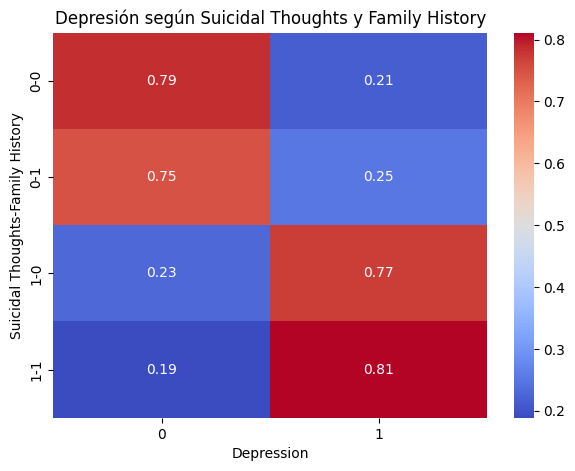

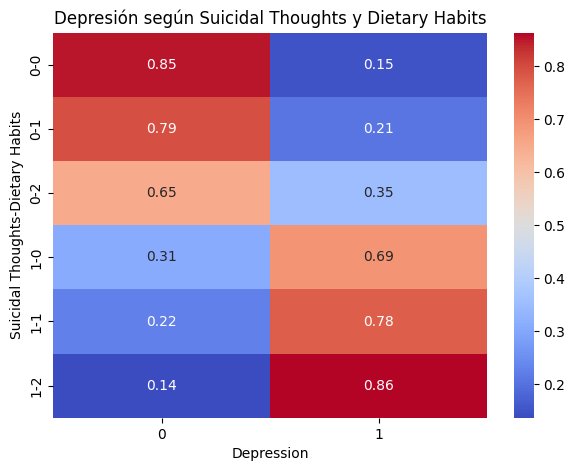

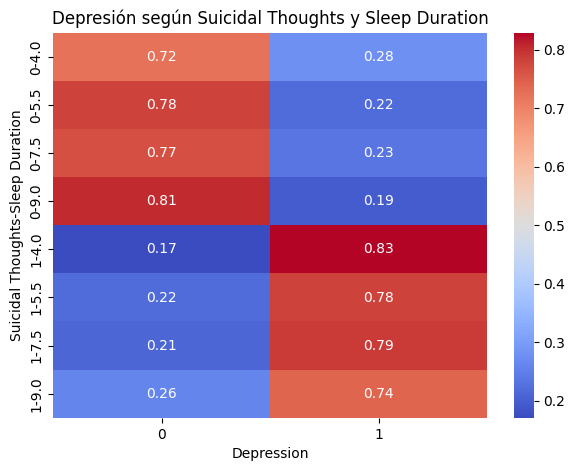

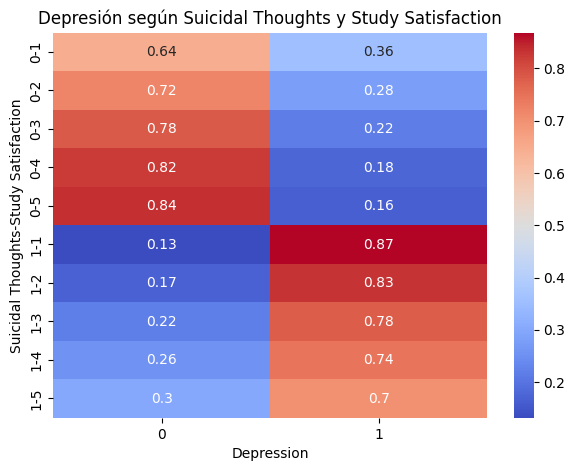

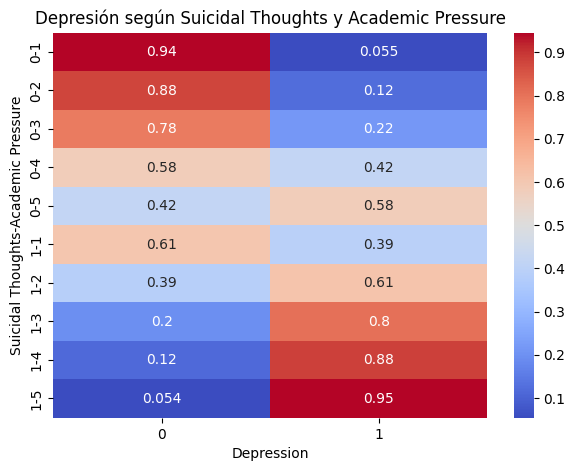

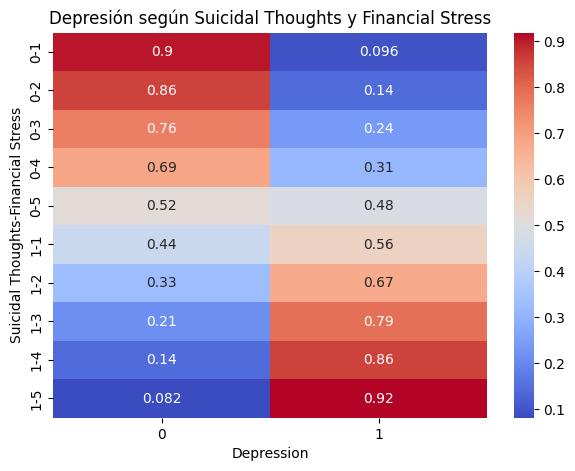

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

variables = [
    'Family History', 'Dietary Habits', 'Sleep Duration',
    'Study Satisfaction', 'Academic Pressure', 'Financial Stress'
]

for var in variables:

    pivot = pd.crosstab(
        [df['Suicidal Thoughts'], df[var]],
        df['Depression'],
        normalize='index'
    )
    plt.figure(figsize=(7, 5))
    sns.heatmap(pivot, annot=True, cmap='coolwarm')
    plt.title(f"Depresión según Suicidal Thoughts y {var}")
    plt.show()


###5.4.2. Dietary Habits con otras variables

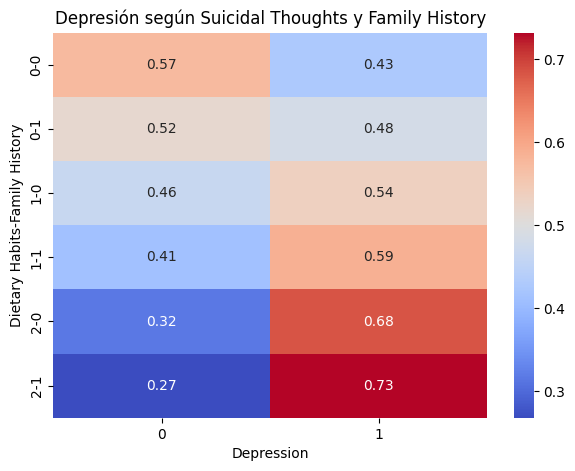

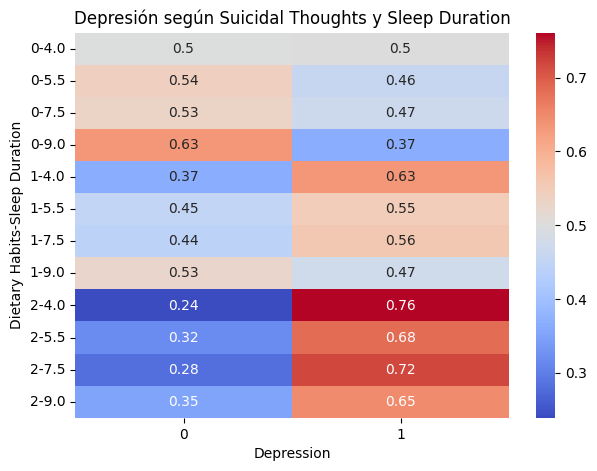

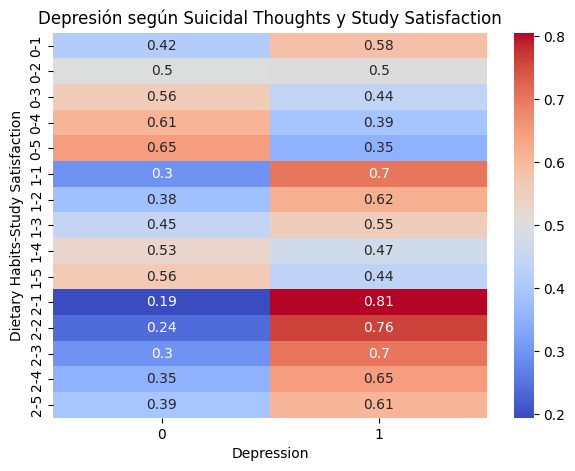

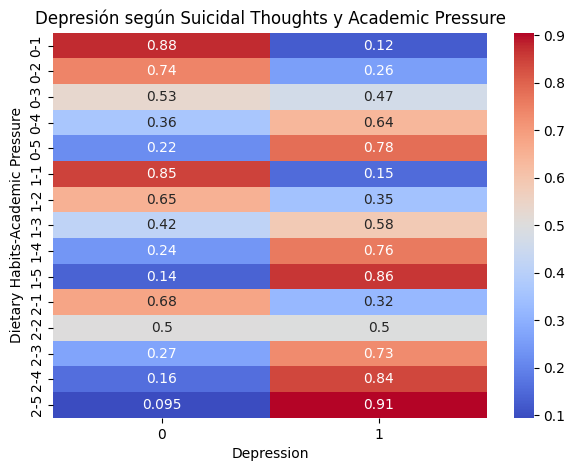

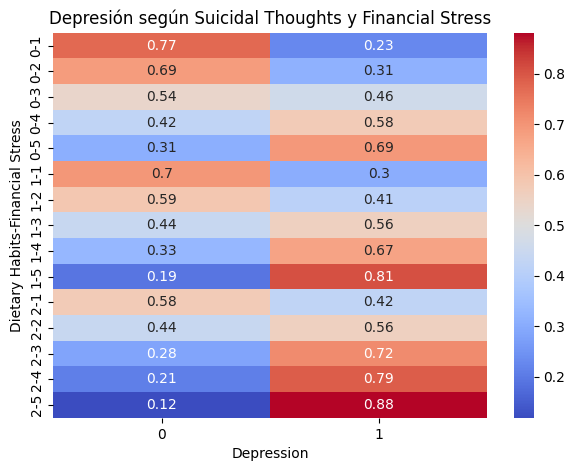

In [ ]:
variables = [
    'Family History', 'Sleep Duration',
    'Study Satisfaction', 'Academic Pressure', 'Financial Stress'
]

for var in variables:

    pivot = pd.crosstab(
        [df['Dietary Habits'], df[var]],
        df['Depression'],
        normalize='index'
    )
    plt.figure(figsize=(7, 5))
    sns.heatmap(pivot, annot=True, cmap='coolwarm')
    plt.title(f"Depresión según Suicidal Thoughts y {var}")
    plt.show()

##5.5. Analisis de correlacion entre variables

###5.5.1. Correlacion para variables Ordinales y Numericas con Spearman

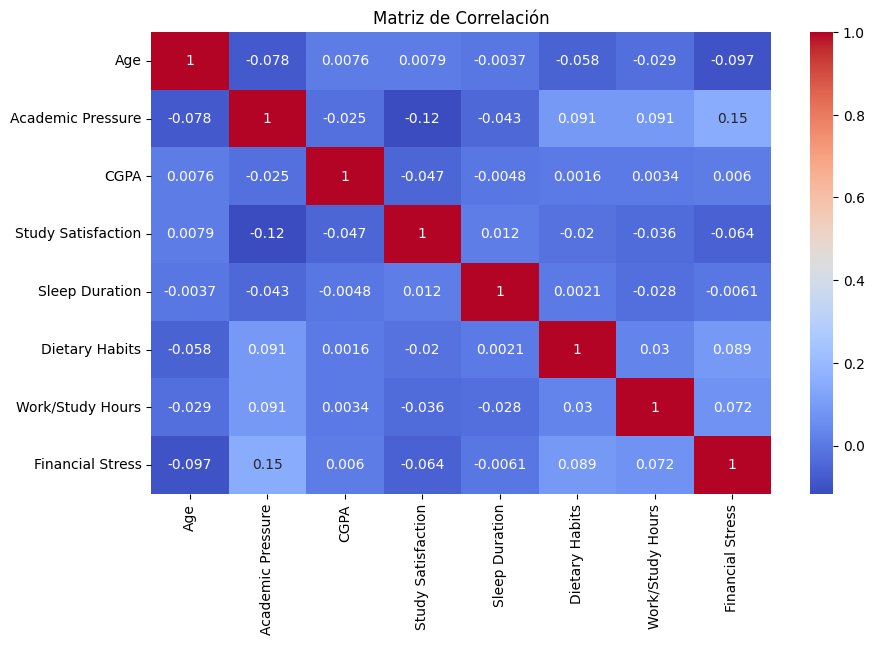

In [ ]:
plt.figure(figsize=(10, 6))
lista = ['Age', 'Academic Pressure', 'CGPA', 'Study Satisfaction',
          'Sleep Duration', 'Dietary Habits',
          'Work/Study Hours', 'Financial Stress']



corr = df[lista].corr(numeric_only=True, method='spearman')
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlación')
plt.show()

###5.5.2. Correlacion para variables Binarias con el coeficiente V de Cramer

In [ ]:
import scipy.stats as ss

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

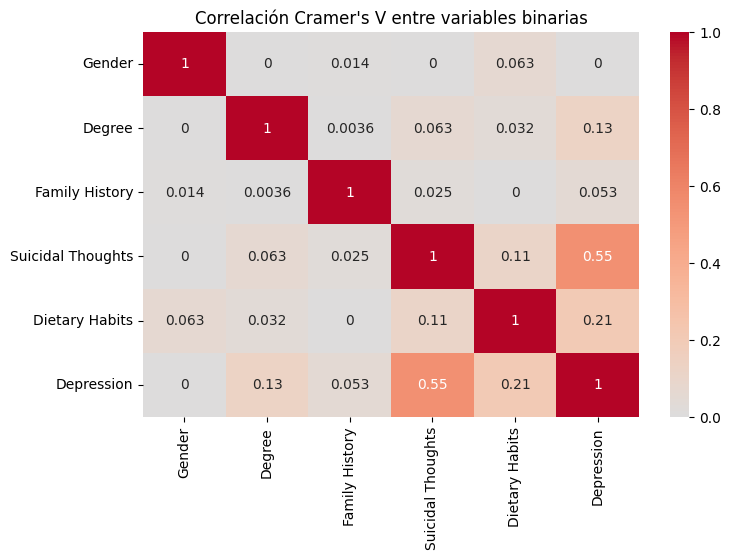

In [ ]:

# Selección de columnas binarias
binary_vars = ['Gender', 'Degree', 'Family History',
               'Suicidal Thoughts',
               'Dietary Habits', 'Depression']
# Matriz vacía
corr_matrix = pd.DataFrame(index=binary_vars, columns=binary_vars)

# Cálculo manual del coeficiente V Cramer
for i in binary_vars:
    for j in binary_vars:
        r = cramers_v(df[i], df[j])
        corr_matrix.loc[i, j] = r

# Convertir a tipo numérico
corr_matrix = corr_matrix.astype(float)

# Matriz grafica
plt.figure(figsize=(8, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Correlación Cramer's V entre variables binarias")
plt.show()

##5.6. Conclusiones del EDA - Dataset Original
El análisis revela que, si bien la depresión es un fenómeno complejo, existen factores y perfiles de riesgo muy claros dentro de la población estudiantil analizada. Los factores más determinantes no son los demográficos (como el género o la edad), sino aquellos relacionados con el bienestar personal, el estrés y las conductas de salud.


A continuación se desglosan los hallazgos clave:
1. Indicadores de Salud Mental y Predictores Más Fuertes (Gráficos de Torta y Heatmap)


* Pensamientos Suicidas (Suicidal Thoughts): Este es, con diferencia, el predictor más potente.
  * Observación: Entre los estudiantes que nunca han tenido pensamientos suicidas, la tasa de depresión es del 23.2%. En contraste, entre aquellos que sí los han tenido, la tasa se dispara al 79.1%.
  * Conclusión: La ideación suicida tiene una asociación altísima con la depresión en este dataset. El mapa de calor de Cramer's V lo confirma con el valor más alto (0.55), indicando una fuerte correlación.


* Tipo de Carrera (Degree): El programa académico es un factor sorprendentemente influyente.
  * Observación: Los estudiantes en el programa de cursado de secundaria (Degree = 0) presentan una tasa de depresión del 70.9%, mientras que alguien en estudios universitarios (Degree = 1) es del 55.2%.
  * Conclusión: Existe una diferencia de más de 15 puntos porcentuales, lo que sugiere que las características, exigencias o el ambiente del programa académico Degree = 0 están fuertemente asociados con una mayor prevalencia de depresión.


* Historial Familiar (Family History): Confirma ser un factor de riesgo, aunque de menor impacto que los anteriores.
  * Observación: La tasa de depresión es ligeramente mayor en estudiantes con historial familiar (61.3%) en comparación con aquellos sin él (56.0%).
  * Conclusión: Si bien es un factor relevante, su poder predictivo por sí solo no es tan abrumador como otros indicadores.


* Género (Gender): En este dataset, el género no parece ser un diferenciador clave.
  * Observación: Las tasas de depresión son prácticamente idénticas entre los dos grupos mostrados (58.7% y 58.5%).
  * Conclusión: A diferencia de lo que se podría esperar, el género no muestra una asociación significativa con la depresión en esta población específica.


2. Estrés y Satisfacción: Una Relación Dosis-Respuesta (Histogramas)
* Estrés Financiero (Financial Stress) y Presión Académica (Academic Pressure):
  * Observación: En ambos gráficos se observa una clara tendencia "dosis-respuesta". A medida que el nivel de estrés (de 1 a 5) aumenta, la proporción de casos de depresión (barra naranja) se hace progresivamente mayor.
  * Conclusión: El estrés, tanto financiero como académico, está fuertemente y positivamente correlacionado con la depresión. No es solo un factor de "sí/no", sino que a mayor intensidad del estrés, mayor es la probabilidad de depresión.


* Satisfacción con los Estudios (Study Satisfaction):
  * Observación: Se observa la tendencia inversa. A medida que la satisfacción aumenta (de 1 a 5), la proporción de casos de depresión (barra naranja) disminuye notablemente.
  * Conclusión: La satisfacción académica actúa como un factor protector. Estudiantes más satisfechos tienen una probabilidad significativamente menor de presentar síntomas depresivos.

3. Hábitos de Vida y su Impacto Directo (Histogramas)
* Duración del Sueño (Sleep Duration):
  * Observación: La falta de sueño está fuertemente asociada con la depresión. La barra con 4 horas de sueño tiene la mayor proporción de casos de depresión. Esta proporción disminuye a medida que las horas de sueño aumentan hacia 7-8 horas.
  * Conclusión: Dormir poco es un claro factor de riesgo. Una duración de sueño adecuada parece ser un factor protector.

* Horas de Estudio/Trabajo (Work/Study Hours): (REVISAR. NO TIENE FORMA DE U)
  * Observación: La relación parece tener forma de "U". La proporción de depresión es alta en los extremos: tanto con muy pocas horas de estudio (posiblemente indicando desmotivación o problemas de asistencia) como, y especialmente, con un número muy elevado de horas (10-12 horas), que sugiere sobrecarga y agotamiento.
  * Conclusión: El exceso de trabajo (burnout) es un claro factor de riesgo. El equilibrio en la carga de trabajo es clave para el bienestar mental.

* Hábitos Alimenticios (Dietary Habits):
  * Observación: Se observa una tendencia clara. A medida que la calidad de los hábitos alimenticios mejora, la proporción de depresión disminuye.
  * Conclusión: Al igual que el sueño, una buena alimentación está asociada a una menor prevalencia de depresión, reforzando la conexión entre salud física y mental.


### 5.6.1. Síntesis y Perfil de Riesgo
Combinando estas conclusiones, podemos construir un perfil del estudiante con mayor riesgo de depresión:

> *Un estudiante inscrito en el programa de estudios Degree = 0, que experimenta altos niveles de estrés académico y financiero, está insatisfecho con sus estudios, duerme poco, trabaja/estudia un número excesivo de horas y, de manera crítica, ha comenzado a tener pensamientos suicidas. Su historial familiar puede o no ser un factor.*

Por el contrario, un perfil de bajo riesgo (o resiliente) sería:


> *Un estudiante con alta satisfacción académica, que maneja una carga de trabajo equilibrada, mantiene buenos hábitos de sueño y alimentación, y enfrenta bajos niveles de estrés.*

# **Parte 6: Aprendizaje No Supervisado - Segmentación de Perfiles Estudiantiles**

## **6.1. Introducción al Enfoque No Supervisado**

En esta sección, daremos un paso atrás de la predicción y trataremos de descubrir la estructura inherente en nuestros datos. Utilizaremos el **clustering**, una técnica de aprendizaje no supervisado, para agrupar a los estudiantes en segmentos distintos basados en sus comportamientos y presiones, **sin usar la etiqueta de 'Depression'**. El objetivo es encontrar "perfiles" naturales que podrían revelar diferentes tipos de experiencias estudiantiles. ¿Existen grupos claramente diferenciados, como "los académicamente exitosos pero estresados" o "los socialmente equilibrados"? El clustering nos ayudará a responder esta pregunta.

## **6.2. Selección de Atributos para Clustering**
Para el análisis de clustering se seleccionaron únicamente los atributos que, según el EDA, presentan una relación clara con los factores de bienestar, estrés y hábitos de vida. Estos incluyen: **Suicidal Thoughts, Academic Pressure, Financial Stress, Study Satisfaction, Sleep Duration, Dietary Habits, Work/Study Hours y Family History**.
Variables demográficas o académicas tradicionales como Gender, Age, CGPA y Degree fueron excluidas porque no mostraron patrones significativos o no aportan variabilidad relevante para la identificación de perfiles mediante aprendizaje no supervisado.

In [1]:
import pandas as pd
import numpy as np
!pip install kmodes
from kmodes.kmodes import KModes
from sklearn import preprocessing
import matplotlib.pyplot as plt

In [ ]:
lista_seleccionados = ['Academic Pressure', 'Study Satisfaction', 'Sleep Duration',
                       'Dietary Habits', 'Suicidal Thoughts',
                       'Financial Stress', 'Family History',  'Work/Study Hours']


# vamos con la lista de atributos elegidos en base al EDA
df2 = df[lista_seleccionados].copy()


print(df2.head())
print(df2.shape)

df2['Work/Study Hours'] = pd.cut(
    df2['Work/Study Hours'],
    bins=[-1, 2, 5, 8, 11, 13],
    labels=[0, 1, 2, 3, 4]
).astype(int)


le = preprocessing.LabelEncoder()
df3 = df2.apply(le.fit_transform)

print(df3.head())

   Academic Pressure  Study Satisfaction  Sleep Duration  Dietary Habits  \
0                5.0                 2.0             5.5               0   
1                2.0                 5.0             5.5               1   
2                3.0                 5.0             4.0               0   
3                3.0                 2.0             7.5               1   
4                4.0                 3.0             5.5               1   

   Suicidal Thoughts  Financial Stress  Family History  Work/Study Hours  
0                  1                 1               0               3.0  
1                  0                 2               1               3.0  
2                  0                 1               1               9.0  
3                  1                 5               1               4.0  
4                  1                 1               0               1.0  
(27774, 8)
   Academic Pressure  Study Satisfaction  Sleep Duration  Dietary Habits  \
0     

##**6.3. Elbow para obtener la cantidad de Clusters**
Para determinar el número óptimo de clústeres para el algoritmo KModes  se aplicó el método del codo (Elbow Method) junto con un análisis de estabilidad e interpretabilidad de los centroides. Ambos procedimientos coincidieron en que 4 clústeres constituyen la mejor elección para este dataset.**

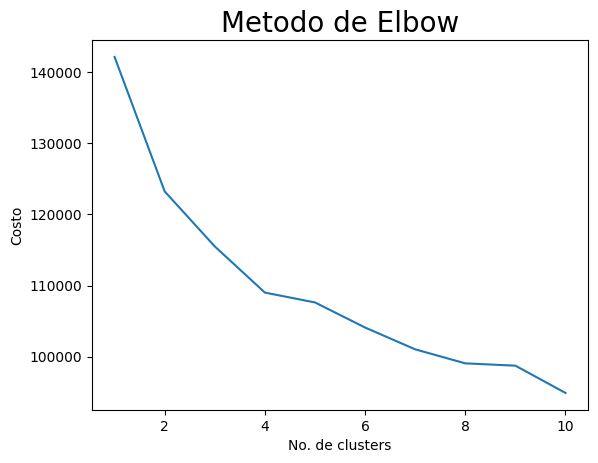

In [ ]:
# Elbow para obtener K
# el metodo de inicializacion puede ser random, Cao, Huang, ...

cost = []
for i in range(1,11):
  modelKmode = KModes(n_clusters=i, init = "Huang", n_init = 10, random_state=31, n_jobs=-1) #, verbose=1)
  modelKmode.fit_predict(df3)
  cost.append(modelKmode.cost_)

plt.plot(range(1,11), cost)
plt.title('Metodo de Elbow', fontsize = 20)
plt.xlabel('No. de clusters')
plt.ylabel('Costo')
plt.show()

## **6.4. Modelo 1: KModes**
Para el modelado no supervisado se utilizó K-Modes, ya que la mayoría de las variables del dataset son categóricas u ordinales. A diferencia de K-Means, este algoritmo trabaja con coincidencias de categorías en lugar de distancias numéricas, por lo que se adapta mejor a la estructura de los datos y permite identificar grupos sin requerir transformaciones adicionales.

In [ ]:
## vamos con 4 clusters. veamos que hay!
k = 4

modelKmode = KModes(n_clusters=k, init = "Huang", n_init = 25, max_iter=300, random_state=31)
y_kmode = modelKmode.fit_predict(df3)

# costo
print('costo: ', modelKmode.cost_)

# centroides
modasDf = pd.DataFrame(modelKmode.cluster_centroids_)
modasDf.columns = df2.columns

print(modasDf)

# cuantos hay por grupo?
print(np.unique(y_kmode, return_counts=True))

#K = 3. costo:  115425.0  [12993,  9501,  5280]
#K = 4. costo:  109019.0  [11655,  5615,  6427,  4077]
#k = 5. costo:  106254.0  [7995, 6787, 6205, 3914, 2873]
#k = 6. costo:  104109.0  [7507, 4613, 5665, 3637, 3510, 2842]
#k = 7. costo:  100151.0  [4480, 6666, 4852, 3841, 3077, 2419, 2439]
#k = 8. costo:  98388.0   [5112, 3266, 7248, 2626, 2175, 3956, 2107, 1284]

costo:  109019.0
   Academic Pressure  Study Satisfaction  Sleep Duration  Dietary Habits  \
0                  4                   0               0               1   
1                  2                   2               1               0   
2                  3                   1               1               2   
3                  0                   3               3               1   

   Suicidal Thoughts  Financial Stress  Family History  Work/Study Hours  
0                  1                 4               1                 3  
1                  0                 1               1                 0  
2                  1                 3               0                 2  
3                  0                 2               0                 2  
(array([0, 1, 2, 3], dtype=uint16), array([11655,  5615,  6427,  4077]))


## 6.4.1. Justificación de la elección de 4 clústeres

Para determinar la cantidad adecuada de clústeres, se analizaron los valores de costo obtenidos por KModes al variar el número de grupos (K). El costo representa el grado de disimilitud interna de los clústeres: valores más bajos indican una mejor compactación y, por lo tanto, una mejor separación entre los grupos.

Los resultados fueron los siguientes:
####K = 3. costo:  115425.0  --- Grupos [12993,  9501,  5280]
####K = 4. costo:  109019.0  --- Grupos [11655,  5615,  6427,  4077]
####k = 5. costo:  106254.0  --- Grupos [7995, 6787, 6205, 3914, 2873]
####k = 6. costo:  104109.0  --- Grupos [7507, 4613, 5665, 3637, 3510, 2842]
####k = 7. costo:  100151.0  --- Grupos [4480, 6666, 4852, 3841, 3077, 2419, 2439]
####k = 8. costo:  98388.0  --- Grupos [5112, 3266, 7248, 2626, 2175, 3956, 2107, 1284]



Se seleccionó K = 4 porque representa el punto donde la disminución del costo es más significativa en comparación con K = 3, mientras que las reducciones adicionales para K > 4 se vuelven marginales. Además, los clústeres obtenidos con K = 4 mantienen tamaños equilibrados y una interpretación clara, evitando la sobre­segmentación observada en valores más altos de K.

##**6.5. Interpretacion de resultados**


Centroides de los Clústeres (perfil de cada grupo):
   Academic Pressure  Study Satisfaction  Sleep Duration  Dietary Habits  \
0                  4                   0               0               1   
1                  2                   2               1               0   
2                  3                   1               1               2   
3                  0                   3               3               1   

   Suicidal Thoughts  Financial Stress  Family History  Work/Study Hours  
0                  1                 4               1                 3  
1                  0                 1               1                 0  
2                  1                 3               0                 2  
3                  0                 2               0                 2  

Proporción de Depresión por Clúster:
Depression         0         1
Cluster                       
0           0.214929  0.785071
1           0.738379  0.261621
2           0.253618  0.74638

<Figure size 1200x600 with 0 Axes>

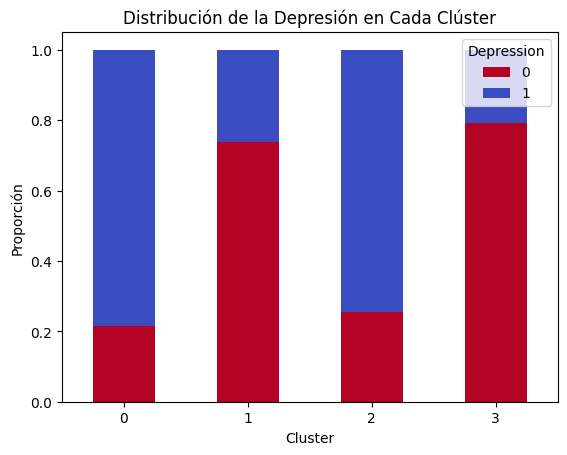

In [ ]:
from joblib import Parallel, delayed
import joblib
modelo_saved = joblib.load(PATH + 'Kmodes_final.pkl')

## Interpretacion de resultados ##
df['Cluster'] = y_kmode

# Obtener los centroides de los clústeres
centroids = pd.DataFrame(modelKmode.cluster_centroids_, columns=df3.columns)
print("\nCentroides de los Clústeres (perfil de cada grupo):")
print(centroids)

# Análisis de la variable objetivo 'Depression' por clúster
cluster_depression = df.groupby('Cluster')['Depression'].value_counts(normalize=True).unstack().fillna(0)
print("\nProporción de Depresión por Clúster:")
print(cluster_depression)

# Visualización
plt.figure(figsize=(12, 6))
cluster_depression.plot(kind='bar', stacked=True, colormap='coolwarm_r')
plt.title('Distribución de la Depresión en Cada Clúster')
plt.ylabel('Proporción')
plt.xticks(rotation=0)
plt.show()

Los centroides obtenidos permitieron identificar **cuatro** perfiles claramente diferenciados dentro del conjunto de estudiantes. La estructura de los clústeres resulta coherente tanto desde la perspectiva estadística como desde la psicológica, ya que cada grupo presenta combinaciones particulares de presión académica, hábitos, estrés, satisfacción y cargas emocionales que explican las diferencias observadas en la proporción de depresión.

A continuación, se describen los clústeres identificados:


###**Clúster 0 – Estudiantes con elevada carga académica y alto riesgo emocional**

Este grupo se caracteriza por una acumulación simultánea de factores de riesgo severos: alta presión académica, carga horaria elevada, estrés financiero muy alto, presencia de pensamientos suicidas y antecedentes familiares. Además, muestra baja satisfacción con los estudios y un sueño muy deficiente. La presencia de pensamientos suicidas agrava considerablemente su vulnerabilidad emocional.

Estos factores combinados reflejan un perfil de sobrecarga académica y vulnerabilidad emocional.

Depresión en el clúster: 78%

Se trata del grupo de mayor riesgo, donde convergen múltiples factores críticos.

###**Clúster 1 – Estudiantes con bajo estrés y bajo riesgo emocional**

Este grupo presenta un perfil relativamente equilibrado: presión académica y estrés financiero bajos, hábitos alimenticios saludables y ausencia de pensamientos suicidas. Aunque poseen antecedentes familiares, sus condiciones actuales de vida y demanda académica son estables. Es un clúster con factores protectores claros, especialmente bajos niveles de estrés.

Este perfil representa a estudiantes con condiciones estables, buena regulación académica y emocional.

Proporción de depresión: 26,1%

Corresponde a un grupo de bajo riesgo, con varios factores protectores presentes: buen sueño, baja carga, poco estrés financiero y hábitos saludables.

###**Clúster 2 – Estudiantes con estrés financiero y moderado riesgo emocional**

Este grupo combina un nivel de presión académica considerable, estrés financiero alto y hábitos alimenticios deficientes. Además, la presencia de pensamientos suicidas indica malestar emocional actual. Aunque carecen de antecedentes familiares, su balance general apunta a una carga de estrés significativa y condiciones que afectan la calidad de vida.

Proporción de depresión: 74,6%

A pesar de no mostrar los niveles más extremos de carga académica, el estrés financiero elevado combinado con hábitos poco saludables se asocia a un riesgo alto de depresión.

###**Clúster 3 – Estudiantes satisfechos con su carrera pero con carga moderada y bajo riesgo**

Este clúster presenta niveles muy bajos de presión académica y alta satisfacción con los estudios, junto con un patrón de sueño muy saludable. No muestran antecedentes familiares ni pensamientos suicidas. A pesar de hábitos alimenticios no ideales, el conjunto actúa como un perfil claramente protector.

Es un perfil que refleja estudiantes con equilibrio académico y bienestar general, donde la carga percibida es baja pero el compromiso y satisfacción académica es alto.

Proporción de depresión: 20,9%

Este es el grupo más saludable emocionalmente, con los indicadores más bajos de riesgo psicológico.

#Parte 7: Aprendizaje Supervisado - Predicción de la Depresión

##7.1. Introducción al Enfoque Supervisado

Ahora pasamos al objetivo principal: la predicción. Utilizaremos **aprendizaje supervisado** para entrenar modelos que aprendan la relación entre las características de los estudiantes y la variable objetivo (`Depression`). El proceso implicará dividir nuestros datos en un conjunto de entrenamiento (para que el modelo aprenda) y uno de prueba (para evaluarlo de forma imparcial). Nos enfocaremos en seleccionar las características más predictivas, optimizar los modelos mediante el ajuste de hiperparámetros y evaluarlos con métricas que sean robustas ante el desbalanceo de clases.

##7.2. Preparación de Datos y Selección de Características (Feature Selection)

Con el objetivo de optimizar el rendimiento de los modelos supervisados y evitar la inclusión de variables redundantes o poco informativas, se realizó un proceso de selección de características **(Feature Selection)**.

Dado que el conjunto de datos está compuesto principalmente por variables categóricas y que la variable objetivo también es categórica, se empleó un método de selección basado en filtro utilizando la prueba Chi-cuadrado (Chi²).

A partir del total de 13 variables disponibles, el análisis permitió identificar 4 características que aportan la mayor relevancia predictiva para los modelos supervisados, reduciendo así la dimensionalidad del problema y mejorando la interpretabilidad del modelo sin comprometer su capacidad de predicción.

In [ ]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
from sklearn.feature_selection import chi2
import seaborn as sns

lista = ['Gender', 'Age', 'Academic Pressure', 'CGPA', 'Study Satisfaction', 'Sleep Duration',
         'Dietary Habits', 'Degree', 'Suicidal Thoughts', 'Work/Study Hours',
         'Financial Stress', 'Family History']

X = df.loc[:, lista]
y = df[df.columns[-1]]


# defino feature selection
k=4
fs = SelectKBest(score_func=chi2, k=k)

# aplico feature selection
X_selected = fs.fit_transform(X, y)


print(X_selected.shape)
print(X_selected)
selected_columns = X.columns[fs.get_support()]
print("Columnas seleccionadas: ")
print(selected_columns)

(27774, 4)
[[ 5.  1.  3.  1.]
 [ 2.  0.  3.  2.]
 [ 3.  0.  9.  1.]
 ...
 [ 3.  0. 12.  2.]
 [ 5.  1. 10.  5.]
 [ 4.  1.  2.  3.]]
Columnas seleccionadas: 
Index(['Academic Pressure', 'Suicidal Thoughts', 'Work/Study Hours',
       'Financial Stress'],
      dtype='object')


##**7.3. Modelo 1: Random Forest**
Para la etapa de Aprendizaje Supervisado se seleccionó el algoritmo Random Forest como primer modelo de clasificación. El objetivo fue predecir la variable Depression, utilizando como predictores un conjunto reducido de características seleccionadas previamente mediante técnicas de Feature Selection. Las variables finalmente empleadas fueron: `Academic Pressure` `Suicidal Thoughts` `Work/Study Hours` `Financial Stress`

Posteriormente, el conjunto de datos se dividió en 75% para entrenamiento y 25% para prueba.

In [ ]:

lista = ['Academic Pressure', 'Suicidal Thoughts', 'Dietary Habits', 'Financial Stress']

X = df[lista].values
y = df['Depression'].values


In [ ]:
## Split del dataset
test_size = 0.25
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size = test_size, random_state = 5)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(20830, 4)
(6944, 4)
(20830,)
(6944,)


In [ ]:
# Creacion, entrenamiento y evaluación del Modelo
modeloRF = RandomForestClassifier(random_state=0, n_estimators=1000, n_jobs=-1)
modeloRF.fit(X_train, y_train)

pred_train = modeloRF.predict(X_train)
pred_test = modeloRF.predict(X_test)


print('Train Accuracy: {:.2f}'.format(accuracy_score(y_train, pred_train)))
print('Tasa de Error: {:.2f}'.format(1 - accuracy_score(y_train, pred_train)))

print('Test Accuracy: {:.2f}'.format(accuracy_score(y_test, pred_test)))
print('Tasa de Error: {:.2f}'.format(1 - accuracy_score(y_test, pred_test)))

print(classification_report(y_test, pred_test))

Train Accuracy: 0.83
Tasa de Error: 0.17
Test Accuracy: 0.84
Tasa de Error: 0.16
              precision    recall  f1-score   support

           0       0.82      0.77      0.80      2876
           1       0.85      0.88      0.86      4068

    accuracy                           0.84      6944
   macro avg       0.83      0.83      0.83      6944
weighted avg       0.84      0.84      0.84      6944



##**7.3.1. Random Forest con Hiperparámetros: RF_v2**
Ahora ejecutaremos el mismo algoritmo pero usando varias combinaciones con diversos Hyperparametros


### **7.3.1.1. Búsqueda de Hiperparámetros (RandomizedSearchCV)**

Con el objetivo de mejorar el desempeño del modelo, aplicamos RandomizedSearchCV, una técnica que prueba combinaciones aleatorias de hiperparámetros dentro de un rango definido.
Esto permite explorar el espacio de búsqueda de forma eficiente sin necesidad de evaluar todas las combinaciones posibles.

Los hiperparámetros evaluados fueron: **n_estimators:** número de árboles, **max_depth:** profundidad máxima del árbol, **min_samples_split:** muestras mínimas para dividir un nodo, **min_samples_leaf:** muestras mínimas por hoja, **max_features:** número de características consideradas al dividir, **class_weight:** balanceo automático de clases, **bootstrap:** si se utiliza muestreo con reemplazo


###**7.3.1.2. Cross Validation**

La optimización se realizó utilizando RepeatedKFold con: 5 folds y 3 repeticiones

Esto implica dividir el conjunto de entrenamiento en 5 partes, entrenar el modelo 5 veces alternando la parte que se usa como validación, y repetir todo el proceso 3 veces.
De esta forma obtenemos una estimación más robusta del rendimiento y evitamos sobreajuste.

###**7.3.1.3. Entrenamiento del Modelo Final**

Luego de la búsqueda, tomamos el mejor conjunto de hiperparámetros encontrados y entrenamos el modelo final con ellos.
Finalmente evaluamos el desempeño sobre los datos de entrenamiento y test para obtener las métricas finales.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RepeatedKFold
from sklearn.metrics import accuracy_score, classification_report
import sklearn
import numpy as np

# Selección de variables
lista = ['Academic Pressure', 'Suicidal Thoughts', 'Work/Study Hours', 'Financial Stress']

X = df[lista].values
y = df['Depression'].values

# Split del dataset
test_size = 0.25
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
    X, y, test_size=test_size, random_state=5
)


# Definición de hiperparámetros a explorar
param_dist = {
    "n_estimators": [300, 500, 800, 1200, 1500],
    "max_depth": [3, 5, 7, 11, 13, 9, 15],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 6, 10],
    "max_features": ["sqrt", "log2", None],
    #"class_weight": ["balanced", None],
    "bootstrap": [True, False]
}

# Configurar modelo base
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# RandomizedSearchCV para optimización

K = RepeatedKFold(n_splits=10, n_repeats=3, random_state=1)  # probar con n_splits=10

search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,
    scoring="f1",
    cv=K,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

print("\nMejores hiperparámetros encontrados:")
print(search.best_params_)


# Modelo final optimizado
best_rf = search.best_estimator_

best_rf.fit(X_train, y_train)

pred_train = best_rf.predict(X_train)
pred_test = best_rf.predict(X_test)


# Métricas finales
print("\n--- Resultados del Modelo Optimizado ---")
print('Train Accuracy: {:.2f}'.format(accuracy_score(y_train, pred_train)))
print('Tasa de Error Train: {:.2f}'.format(1 - accuracy_score(y_train, pred_train)))

print('Test Accuracy: {:.2f}'.format(accuracy_score(y_test, pred_test)))
print('Tasa de Error Test: {:.2f}'.format(1 - accuracy_score(y_test, pred_test)))

print("\n--- Classification Report (Test) ---")
print(classification_report(y_test, pred_test))

Fitting 15 folds for each of 30 candidates, totalling 450 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Mejores hiperparámetros encontrados:
{'n_estimators': 1200, 'min_samples_split': 10, 'min_samples_leaf': 10, 'max_features': 'log2', 'max_depth': 15, 'class_weight': None, 'bootstrap': True}

--- Resultados del Modelo Optimizado ---
Train Accuracy: 0.83
Tasa de Error Train: 0.17
Test Accuracy: 0.83
Tasa de Error Test: 0.17

--- Classification Report (Test) ---
              precision    recall  f1-score   support

           0       0.81      0.76      0.79      2876
           1       0.84      0.87      0.86      4068

    accuracy                           0.83      6944
   macro avg       0.82      0.82      0.82      6944
weighted avg       0.83      0.83      0.83      6944



In [ ]:
#Para guardar el modelo
from joblib import Parallel, delayed
import joblib

modelName = 'RFHyperparametros.pkl'

# grabando modelo
joblib.dump(best_rf, PATH + modelName)

['gdrive/My Drive/datasets/RFHyperparametros.pkl']

##**7.3.2. Métricas de Performance del Modelo RF**

Para evaluar el desempeño del modelo Random Forest se utilizaron tanto el conjunto de entrenamiento como el de prueba. Las métricas obtenidas muestran un rendimiento consistente entre ambos conjuntos, lo que indica que el modelo generaliza adecuadamente y no presenta signos evidentes de Overfitting.

Los resultados fueron los siguientes:

**Train Accuracy: 0.83**

**Test Accuracy: 0.83**

Además, se analizó el comportamiento del modelo para cada clase mediante las métricas de `precision`, `recall` y `F1-score`:

El modelo logra un accuracy global del 83%, con un desempeño equilibrado en ambas clases. El promedio macro (macro avg) muestra valores de 0.82 en precision, recall y F1, indicando que el modelo mantiene un rendimiento estable sin que una clase domine en exceso el aprendizaje. El promedio ponderado (weighted avg) confirma la misma tendencia con un valor de 0.83.


En conjunto, estas métricas indican que el Random Forest ofrece una capacidad predictiva sólida para identificar casos de depresión dentro del dataset, con buena precisión y sensibilidad especialmente en la clase positiva.

##**7.3.3. Matriz de confusión para RF**

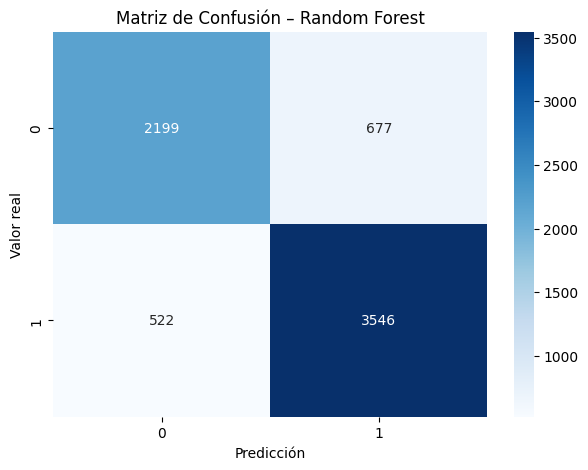

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Obtener la matriz de confusión
cm = confusion_matrix(y_test, pred_test)

# 2. Visualizar
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de Confusión – Random Forest")
plt.show()

##**7.4. Modelo 2: XGBoost**

> Agregar bloque entrecomillado


Como segundo algoritmo de Aprendizaje Supervisado se empleó XGBoost.
Al igual que en el Random Forest, el objetivo fue predecir la variable objetivo `Depression`, utilizando el mismo conjunto reducido de características previamente seleccionadas mediante Feature Selection:
`Academic Pressure`, `Suicidal Thoughts`, `Work/Study Hours` y `Financial Stress`.

In [ ]:
!pip install xgboost
import xgboost as xgb

lista = ['Academic Pressure', 'Suicidal Thoughts', 'Work/Study Hours', 'Financial Stress']

X = df[lista].values
y = df['Depression'].values

In [ ]:
## Split del dataset
test_size = 0.25
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size = test_size, random_state = 5)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(20830, 4)
(6944, 4)
(20830,)
(6944,)


In [ ]:
# Creacion, entrenamiento y evaluación del Modelo
lr = 0.025
modelo = xgb.XGBClassifier(eta = lr, n_estimators=3000, n_jobs=-1)
modelo.fit(X_train, y_train)


pred_train = modelo.predict(X_train)
pred_test = modelo.predict(X_test)


print('Train Accuracy: {:.2f}'.format(accuracy_score(y_train, pred_train)))
print('Tasa de Error: {:.2f}'.format(1 - accuracy_score(y_train, pred_train)))

print('Test Accuracy: {:.2f}'.format(accuracy_score(y_test, pred_test)))
print('Tasa de Error: {:.2f}'.format(1 - accuracy_score(y_test, pred_test)))

print(classification_report(y_test, pred_test))

Train Accuracy: 0.84
Tasa de Error: 0.16
Test Accuracy: 0.82
Tasa de Error: 0.18
              precision    recall  f1-score   support

           0       0.80      0.75      0.78      2876
           1       0.83      0.87      0.85      4068

    accuracy                           0.82      6944
   macro avg       0.82      0.81      0.81      6944
weighted avg       0.82      0.82      0.82      6944



##**7.4.1. XGBost con Hiperparámetros: XGBv2**
Con el objetivo de mejorar el desempeño del modelo, se llevó a cabo un proceso de búsqueda de hiperparámetros, evaluando distintas combinaciones mediante RandomizedSearchCV junto con Cross Validation. En este caso usamos kfold.
Entre los principales hiperparámetros explorados se encuentran:

**n_estimators:** número de árboles en el ensamble

**learning_rate:** tasa de aprendizaje

**max_depth:** profundidad máxima de los árboles

**subsample:** proporción de datos usados en cada árbol

**colsample_bytree:** proporción de variables usadas por árbol

**min_child_weight:** complejidad mínima para realizar una partición

**gamma:** umbral para permitir nuevas divisiones

**reg_alpha y reg_lambda:** términos de regularización L1 y L2

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.model_selection import RepeatedKFold
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier


# Selección de columnas
lista = ['Academic Pressure', 'Suicidal Thoughts', 'Work/Study Hours', 'Financial Stress']

X = df[lista].copy()
y = df['Depression'].copy()

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=5, stratify=y
)


# Espacio de hiperparámetros
param_dist = {
    "n_estimators": [300, 700, 1000, 1500],               # más árboles => mejor accuracy
    "learning_rate": [0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.25, 0.3], # LR pequeño => mayor precisión final
    "max_depth": [3, 5, 6, 7, 9, 11, 13],                             # árboles más expresivos
    "subsample": [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],                     # reduce overfitting
    "colsample_bytree": [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],              # usar más features mejora accuracy
    "min_child_weight": [1, 3, 5, 7, 10],                            # permite árboles más detallados
    "gamma": [0, 0.05, 0.1, 0.2],                                    # 0 => más divisiones => mayor accuracy
    "reg_alpha": [0, 0.1, 0.5, 1, 2],                                # menos regularización para más flexibilidad
    "reg_lambda": [0.5, 1, 2, 3]                                     # evita overfitting excesivo
}

# Definir CV
K = RepeatedKFold(n_splits=10, n_repeats=3, random_state=1)  # probar con n_splits=10


# RandomizedSearchCV
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    n_jobs=-1,
    random_state=42
)

search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=40,                 # probar 40 combinaciones
    scoring="f1",
    cv=K,                 # cross validation
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

print("\n Mejores hiperparámetros encontrados:")
print(search.best_params_)

# Modelo final optimizado
best_xgb = search.best_estimator_
best_xgb.fit(X_train, y_train)

pred_train = best_xgb.predict(X_train)
pred_test = best_xgb.predict(X_test)


# Métricas
print("\n--- Resultados finales ---")
print('Train Accuracy: {:.2f}'.format(accuracy_score(y_train, pred_train)))
print('Tasa de Error: {:.2f}'.format(1 - accuracy_score(y_train, pred_train)))

print('Test Accuracy: {:.2f}'.format(accuracy_score(y_test, pred_test)))
print('Tasa de Error: {:.2f}'.format(1 - accuracy_score(y_test, pred_test)))

print(classification_report(y_test, pred_test))


Fitting 30 folds for each of 40 candidates, totalling 1200 fits

 Mejores hiperparámetros encontrados:
{'subsample': 1.0, 'reg_lambda': 3, 'reg_alpha': 0.5, 'n_estimators': 300, 'min_child_weight': 7, 'max_depth': 11, 'learning_rate': 0.01, 'gamma': 0.05, 'colsample_bytree': 0.7}

--- Resultados finales ---
Train Accuracy: 0.83
Tasa de Error: 0.17
Test Accuracy: 0.83
Tasa de Error: 0.17
              precision    recall  f1-score   support

           0       0.83      0.73      0.78      2876
           1       0.83      0.89      0.86      4068

    accuracy                           0.83      6944
   macro avg       0.83      0.81      0.82      6944
weighted avg       0.83      0.83      0.82      6944



##**7.4.2. Métricas de Performance del Modelo XGBoost**
Para el desempeñode XGBost utilizamos las mismas metricas usadas en el modelo RF.
A partir del conjunto de prueba, las métricas obtenidas fueron las siguientes:

**Train Accuracy: 0.83**

**Test Accuracy: 0.83**

El modelo logra un accuracy global de 83%. A nivel de clases, el modelo muestra un comportamiento equilibrado con un promedio de 0.82 para maco avg como para wighted avg.

Se observa un mejor rendimiento en la detección de estudiantes con depresión, lo cual es relevante para este analisis ya que ese es el objetivo del mismo.

##**7.4.3. Matriz de confusión XGBoost**

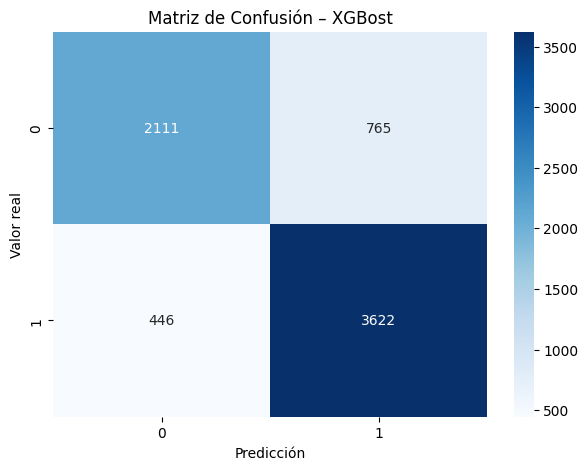

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Obtener la matriz de confusión
cm = confusion_matrix(y_test, pred_test)

# 2. Visualizar
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de Confusión – XGBost")
plt.show()

#Parte 8: Conclusiones y Discusión Final

##8.1. Síntesis de los Hallazgos del Proyecto
Este proyecto se propuso abordar el complejo problema de la depresión estudiantil desde una doble perspectiva: la segmentación para entender los perfiles de riesgo y la predicción para identificar a los individuos vulnerables. A través de un análisis metódico, hemos logrado extraer insights significativos que confirman y cuantifican los factores asociados a la salud mental en esta población.
Los resultados de las tres fases principales del proyecto (Análisis Exploratorio, Clustering No Supervisado y Modelado Supervisado) convergen en una narrativa coherente: la depresión estudiantil está más fuertemente ligada al bienestar personal, los niveles de estrés y los hábitos de vida que a los factores demográficos tradicionales.

##8.2. Hallazgos Clave del Análisis Exploratorio (EDA)
El EDA sentó las bases de nuestro entendimiento, revelando varias relaciones cruciales:
El Predictor Dominante: La presencia de ideación suicida demostró ser el indicador más potente, con una tasa de depresión que se dispara del 23.2% al 79.1% en estudiantes que la han experimentado.
El Efecto "Dosis-Respuesta": Variables como el estrés académico/financiero y la satisfacción con los estudios no actúan como simples interruptores, sino que muestran una clara relación gradual. A mayor estrés, mayor prevalencia de depresión; a mayor satisfacción, menor prevalencia.
La Conexión Mente-Cuerpo: Los hábitos de vida como la duración del sueño y la calidad de la dieta mostraron una fuerte asociación con la salud mental, confirmando que el bienestar físico y el psicológico están intrínsecamente ligados.

##8.3. Perfiles de Riesgo Descubiertos por el Clustering (Aprendizaje No Supervisado)

El modelo de clustering K-Modes no solo agrupó a los estudiantes, sino que validó los hallazgos del EDA al crear "personas" o perfiles de riesgo coherentes y accionables. Logramos identificar cuatro segmentos muy claros:
* Grupo de Bajo Riesgo (Clúster 1 y 3 - "Resilientes y Satisfechos"): Con tasas de depresión del 26.1% y 20.9%, estos estudiantes se caracterizan por bajos niveles de estrés, alta satisfacción y, crucialmente, la ausencia de ideación suicida. Actúan como un "grupo de control" que define el bienestar en este contexto.
* Grupo de Riesgo Alto (Clúster 2 - "Vulnerables por Estrés"): A pesar de la ausencia de antecedentes familiares, la combinación de alto estrés financiero y pensamientos suicidas eleva su tasa de depresión al 74.6%. Este perfil destaca la importancia de las presiones externas como detonantes.
* Grupo de Riesgo Crítico (Clúster 0 - "La Tormenta Perfecta"): Este es el perfil más alarmante. La confluencia de alta carga académica, estrés financiero, antecedentes familiares e ideación suicida resulta en una devastadora tasa de depresión del 78%. Este grupo requiere una atención prioritaria e inmediata.

El clustering demuestra que el riesgo no es un concepto único, sino un espectro con diferentes arquetipos, cada uno potencialmente requiriendo un tipo de intervención distinta

##8.4. Rendimiento de los Modelos Predictivos (Aprendizaje Supervisado)

El objetivo final era construir modelos capaces de identificar a los estudiantes en riesgo. Para ello, evaluamos Random Forest y XGBoost, dos potentes algoritmos de ensamble.

###Rendimiento General (Accuracy y Error)

Tanto Random Forest como XGBoost alcanzaron un Test Accuracy de 0.83, con una Tasa de Error del 17%. Esto muestra que, en términos de rendimiento global, ambos modelos tienen un desempeño prácticamente equivalente y son capaces de clasificar correctamente aproximadamente el 80% de los estudiantes.

###Análisis por Clase

Sin embargo, al revisar métricas más específicas como precision, recall y f1-score, surgen diferencias relevantes:

####**Clase 0 (estudiantes sin depresión)**

Random Forest: tiene un mejor recall (0.76 vs 0.73), lo cual significa que detecta una mayor proporción de casos negativos reales.

XGBoost: muestra una precision algo superior (0.83 vs 0.81), lo que implica que sus predicciones negativas tienen menor proporción de falsos positivos.

####**Clase 1 (estudiantes con depresión)**

Aquí ambos modelos son fuertes, pero hay algunas diferencias:

Random Forest: recall = 0.87

XGBoost: recall = 0.89

El modelo XGBoost logra detectar más estudiantes que efectivamente presentan depresión (mejor sensibilidad), mientras que ambos mantienen una precisión similar (~0.83–0.84).
El f1-score de ambos modelos es también muy parecido (≈0.86).

###Evaluación Global

Random Forest ofrece un rendimiento balanceado y ligeramente mejor para la clase negativa.

XGBoost muestra mejor capacidad para identificar correctamente a los estudiantes con depresión, lo que es especialmente importante dado que esta es la clase de interés principal.

###Conclusion
Ambos modelos muestran un rendimiento sólido y muy similar en términos globales. Sin embargo, XGBoost resulta ligeramente superior para la detección correcta de estudiantes en riesgo (clase 1), lo que lo convierte en el modelo más adecuado para este caso de estudio cuando el objetivo prioritario es minimizar falsos negativos.

## 8.5. Conclusión General y Trabajo Futuro
Este proyecto ha demostrado exitosamente cómo las técnicas de Machine Learning pueden ser aplicadas para desentrañar un problema complejo de salud pública. Hemos pasado de un conjunto de datos crudo a la identificación de factores de riesgo clave, la creación de perfiles de vulnerabilidad accionables y el desarrollo de modelos predictivos de alto rendimiento.

##Trabajo Futuro

A partir de los resultados obtenidos en este proyecto, se identifican varias líneas de trabajo futuras que permitirían profundizar, validar y ampliar el impacto del modelo desarrollado:

1. Aplicación en un entorno cercano (UNSa)

    Un paso relevante sería implementar un prototipo funcional del modelo dentro del contexto real de la Universidad Nacional de Salta. Esto permitiría:

* Detectar estudiantes en situación de vulnerabilidad emocional, específicamente aquellos con riesgo elevado de depresión.

* Generar alertas tempranas, orientadas a áreas de bienestar estudiantil, tutorías o servicios psicopedagógicos.

* Ofrecer sugerencias preventivas basadas en los factores de riesgo identificados (estrés académico, presión financiera, hábitos de sueño, etc.).

La implementación local podría convertir este modelo en una herramienta concreta de apoyo institucional.

2. Validación con datos reales locales

    Para evaluar la robustez del modelo, sería fundamental trabajar con un dataset propio de la comunidad estudiantil de la UNSa. Esto permitiría:

* Medir la validez externa del modelo, es decir, comprobar si mantiene su desempeño con datos reales del contexto local.

* Ajustar los factores predictivos, adaptando los parámetros del modelo a patrones propios de la población estudiantil salteña.

* Detectar posibles sesgos, derivados de diferencias culturales, socioeconómicas o académicas.

La validación local consolidaría la aplicabilidad práctica del sistema.

3. Ampliación a otras problemáticas estudiantiles

    La metodología utilizada —EDA exhaustivo, modelos supervisados y no supervisados, métricas de evaluación y análisis interpretativo— puede extenderse a otros fenómenos relevantes dentro del ámbito universitario. Algunas líneas posibles incluyen:

* Ansiedad académica

* Burnout estudiantil

* Rendimiento académico crítico

* Riesgo de abandono universitario

Explorar estos casos permitiría construir un sistema predictivo integral para el bienestar estudiantil.